In [684]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
# from lightgbm import LGBMClassifier
# from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
# from lightgbm import LGBMRegressor
# from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth

# 학습 모델 저장을 위한 라이브러리
import pickle

In [653]:
import pandas as pd
import gc

In [655]:
# parquet 파일 데이터를 읽어온다.
df1 = pd.read_parquet('open/train/5.잔액정보/201807_train_잔액정보.parquet')
df1

,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,...,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
0,201807,TRAIN_000000,998,962,22971,0,0,0,1084,547,...,15988,2440,0,0,0,572,0,17008,0,0
1,201807,TRAIN_000001,2565,2390,0,0,0,0,4090,2553,...,7045,2677,0,2830,0,2736,0,0,0,0
2,201807,TRAIN_000002,5312,5113,21531,6795,0,0,5006,8778,...,66549,9118,0,8870,0,4429,0,43351,0,0
3,201807,TRAIN_000003,730,5025,26284,0,0,0,487,5607,...,30139,884,0,0,0,5097,0,30697,0,0
4,201807,TRAIN_000004,0,0,0,0,0,0,0,0,...,28,21,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,201807,TRAIN_399995,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
399996,201807,TRAIN_399996,6374,0,0,0,0,29839,10598,0,...,102577,16321,0,0,0,246,0,0,0,37252
399997,201807,TRAIN_399997,2168,0,0,0,0,0,1831,0,...,8367,1665,0,0,0,5700,0,0,0,0
399998,201807,TRAIN_399998,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [657]:
# parquet 파일 데이터를 읽어온다.
df2 = pd.read_parquet('open/test/5.잔액정보/201807_test_잔액정보.parquet')
df2

,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,...,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
0,201807,TEST_00000,4802,0,0,0,0,0,6412,0,...,3847,2933,384,0,0,0,0,0,0,0
1,201807,TEST_00001,1201,8628,5448,0,0,24299,1010,8156,...,42634,657,0,0,0,7979,0,1530,0,31707
2,201807,TEST_00002,3046,6144,0,0,0,0,4407,8033,...,22936,6253,0,0,0,12329,0,0,0,0
3,201807,TEST_00003,768,945,0,0,0,0,1107,674,...,1206,819,0,0,0,468,0,0,0,0
4,201807,TEST_00004,637,2558,0,0,0,0,1072,3690,...,2914,979,0,0,0,2414,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,201807,TEST_99995,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,201807,TEST_99996,282,0,0,0,0,0,366,0,...,542,443,0,0,0,0,0,0,0,0
99997,201807,TEST_99997,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99998,201807,TEST_99998,18924,2697,0,0,0,0,20859,2104,...,16787,13069,358,0,0,2996,0,0,0,0


### 데이터를 읽어온다. + 월 합치기

In [660]:
# Train
# 대상 월
months = ['07', '08', '09', '10', '11', '12']

# 파일 리스트 생성
file_list = [f'open/train/5.잔액정보/2018{month}_train_잔액정보.parquet' for month in months]

# 실제로 어떤 파일 불러올지 확인
for f in file_list:
    print(f)

# 불러오기 + 리스트에 저장
df_list = []
for month, file in zip(months, file_list):
    try:
        df = pd.read_parquet(file)
        df['기준년월'] = f'2018{month}'  # 월 정보 명시적으로 컬럼 추가 (이미 있으면 생략)
        df_list.append(df)
    except FileNotFoundError:
        print(f'⚠️ 파일 없음: {file}')

# 하나로 합치기
train_df = pd.concat(df_list, ignore_index=True)

# 결과 확인
print(f'전체 행 수: {train_df.shape[0]}')
print(train_df['기준년월'].value_counts().sort_index())

open/train/5.잔액정보/201807_train_잔액정보.parquet
open/train/5.잔액정보/201808_train_잔액정보.parquet
open/train/5.잔액정보/201809_train_잔액정보.parquet
open/train/5.잔액정보/201810_train_잔액정보.parquet
open/train/5.잔액정보/201811_train_잔액정보.parquet
open/train/5.잔액정보/201812_train_잔액정보.parquet
전체 행 수: 2400000
기준년월
201807    400000
201808    400000
201809    400000
201810    400000
201811    400000
201812    400000
Name: count, dtype: int64


In [661]:
# Test
# 대상 월
months = ['07', '08', '09', '10', '11', '12']

# 파일 리스트 생성
file_list = [f'open/test/5.잔액정보/2018{month}_test_잔액정보.parquet' for month in months]

# 실제로 어떤 파일 불러올지 확인
for f in file_list:
    print(f)

# 불러오기 + 리스트에 저장
df_list = []
for month, file in zip(months, file_list):
    try:
        df = pd.read_parquet(file)
        df['기준년월'] = f'2018{month}'  # 월 정보 명시적으로 컬럼 추가 (이미 있으면 생략)
        df_list.append(df)
    except FileNotFoundError:
        print(f'⚠️ 파일 없음: {file}')

# 하나로 합치기
test_df = pd.concat(df_list, ignore_index=True)

# 결과 확인
print(f'전체 행 수: {test_df.shape[0]}')
print(test_df['기준년월'].value_counts().sort_index())

open/test/5.잔액정보/201807_test_잔액정보.parquet
open/test/5.잔액정보/201808_test_잔액정보.parquet
open/test/5.잔액정보/201809_test_잔액정보.parquet
open/test/5.잔액정보/201810_test_잔액정보.parquet
open/test/5.잔액정보/201811_test_잔액정보.parquet
open/test/5.잔액정보/201812_test_잔액정보.parquet
전체 행 수: 600000
기준년월
201807    100000
201808    100000
201809    100000
201810    100000
201811    100000
201812    100000
Name: count, dtype: int64


In [664]:
# 두 데이터 프레임을 합친다.
all_df = pd.concat([train_df, test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,...,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
0,201807,TRAIN_000000,998,962,22971,0,0,0,1084,547,...,15988,2440,0,0,0,572,0,17008,0,0
1,201807,TRAIN_000001,2565,2390,0,0,0,0,4090,2553,...,7045,2677,0,2830,0,2736,0,0,0,0
2,201807,TRAIN_000002,5312,5113,21531,6795,0,0,5006,8778,...,66549,9118,0,8870,0,4429,0,43351,0,0
3,201807,TRAIN_000003,730,5025,26284,0,0,0,487,5607,...,30139,884,0,0,0,5097,0,30697,0,0
4,201807,TRAIN_000004,0,0,0,0,0,0,0,0,...,28,21,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,201812,TEST_99995,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2999996,201812,TEST_99996,191,0,0,0,0,0,260,0,...,275,137,0,0,0,0,0,0,0,0
2999997,201812,TEST_99997,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2999998,201812,TEST_99998,17916,2786,0,0,0,0,16911,2081,...,20549,18108,240,0,0,1830,0,0,0,0


In [665]:
# 컬럼명 확인
all_df.columns

Index(['기준년월', 'ID', '잔액_일시불_B0M', '잔액_할부_B0M', '잔액_현금서비스_B0M',
       '잔액_리볼빙일시불이월_B0M', '잔액_리볼빙CA이월_B0M', '잔액_카드론_B0M', '월중평잔_일시불_B0M',
       '월중평잔_할부_B0M', '월중평잔_CA_B0M', '카드론잔액_최종경과월', '연체일자_B0M', '연체잔액_B0M',
       '연체잔액_일시불_B0M', '연체잔액_할부_B0M', '연체잔액_현금서비스_B0M', '연체잔액_카드론_B0M',
       '연체잔액_대환론_B0M', '잔액_현금서비스_B1M', '잔액_현금서비스_B2M', '잔액_카드론_B1M',
       '잔액_카드론_B2M', '잔액_카드론_B3M', '잔액_카드론_B4M', '잔액_카드론_B5M', '잔액_할부_B1M',
       '잔액_할부_B2M', '잔액_일시불_B1M', '잔액_일시불_B2M', '연체일수_B1M', '연체일수_B2M',
       '연체원금_B1M', '연체원금_B2M', '연체일수_최근', '연체원금_최근', '최종연체회차', '매각잔액_B1M',
       '최종연체개월수_R15M', 'RV_평균잔액_R12M', 'RV_최대잔액_R12M', 'RV_평균잔액_R6M',
       'RV_최대잔액_R6M', 'RV_평균잔액_R3M', 'RV_최대잔액_R3M', 'RV잔액이월횟수_R6M',
       'RV잔액이월횟수_R3M', '잔액_할부_유이자_B0M', '잔액_할부_무이자_B0M', '잔액_할부_해외_B0M',
       '연체잔액_일시불_해외_B0M', '연체잔액_RV일시불_B0M', '연체잔액_RV일시불_해외_B0M',
       '연체잔액_할부_해외_B0M', '연체잔액_CA_B0M', '연체잔액_CA_해외_B0M', '월중평잔', '월중평잔_일시불',
       '월중평잔_RV일시불', '월중평잔_할부', '월중평잔_CA', '월중평잔_카드론', '평잔_3M', '평잔_

In [668]:
# 데이터 프레임 정보 확인
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 82 columns):
 #   Column             Dtype  
---  ------             -----  
 0   기준년월               object 
 1   ID                 object 
 2   잔액_일시불_B0M         int64  
 3   잔액_할부_B0M          int64  
 4   잔액_현금서비스_B0M       int64  
 5   잔액_리볼빙일시불이월_B0M    int64  
 6   잔액_리볼빙CA이월_B0M     int64  
 7   잔액_카드론_B0M         int64  
 8   월중평잔_일시불_B0M       int64  
 9   월중평잔_할부_B0M        int64  
 10  월중평잔_CA_B0M        int64  
 11  카드론잔액_최종경과월        int64  
 12  연체일자_B0M           float64
 13  연체잔액_B0M           int64  
 14  연체잔액_일시불_B0M       int64  
 15  연체잔액_할부_B0M        int64  
 16  연체잔액_현금서비스_B0M     int64  
 17  연체잔액_카드론_B0M       int64  
 18  연체잔액_대환론_B0M       int64  
 19  잔액_현금서비스_B1M       int64  
 20  잔액_현금서비스_B2M       int64  
 21  잔액_카드론_B1M         int64  
 22  잔액_카드론_B2M         int64  
 23  잔액_카드론_B3M         int64  
 24  잔액_카드론_B4M         int64  
 25  잔액_카드론_B5M        

In [670]:
# 결측치 확인
all_df.isna().sum()

기준년월            0
ID              0
잔액_일시불_B0M      0
잔액_할부_B0M       0
잔액_현금서비스_B0M    0
               ..
평잔_할부_6M        0
평잔_할부_해외_6M     0
평잔_CA_6M        0
평잔_CA_해외_6M     0
평잔_카드론_6M       0
Length: 82, dtype: int64

---

## 잔액
### 잔액_일시불_B0M
- BOM : Beginning of Month (월초 시점) 기준년월의 월초 시점 잔액

In [66]:
all_df['잔액_일시불_B0M'].value_counts()

잔액_일시불_B0M
0        858154
7          1546
8          1544
9          1363
10         1211
          ...  
73352         1
39756         1
87865         1
39660         1
56513         1
Name: count, Length: 49951, dtype: int64

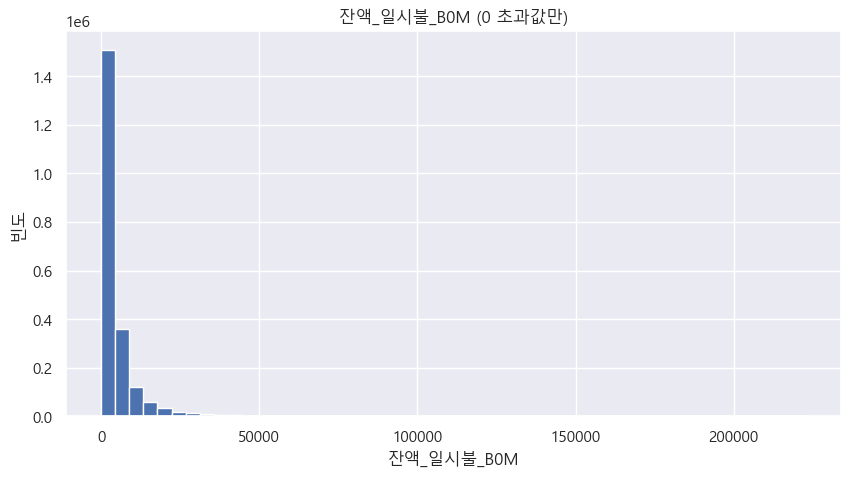

In [590]:
used = all_df[all_df['잔액_일시불_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_일시불_B0M'],
    bins=50,
)
plt.title('잔액_일시불_B0M (0 초과값만)')
plt.xlabel('잔액_일시불_B0M')
plt.ylabel('빈도')
plt.show()


### 잔액_할부_B0M

In [72]:
all_df['잔액_할부_B0M'].value_counts()

잔액_할부_B0M
0        2038700
1601         344
1809         343
1714         343
1712         340
          ...   
37273          1
33015          1
35442          1
23363          1
27201          1
Name: count, Length: 28506, dtype: int64

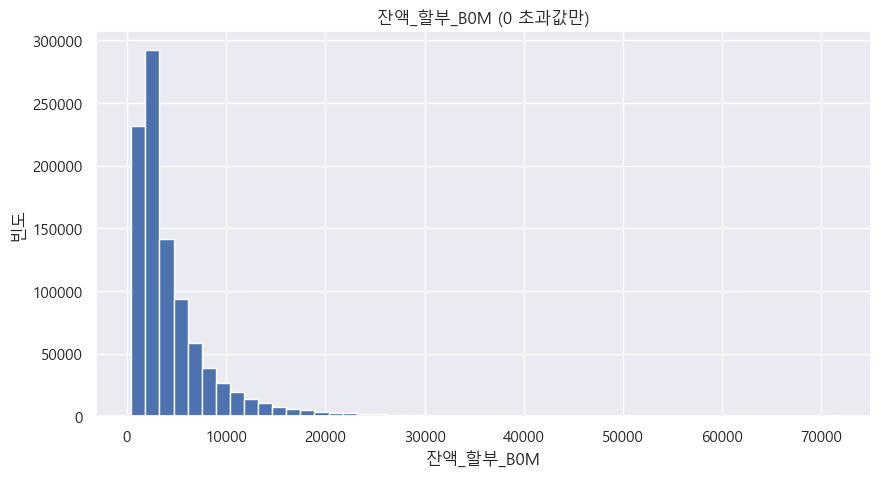

In [592]:
used = all_df[all_df['잔액_할부_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_할부_B0M'],
    bins=50,
)
plt.title('잔액_할부_B0M (0 초과값만)')
plt.xlabel('잔액_할부_B0M')
plt.ylabel('빈도')
plt.show()


### 잔액_현금서비스_BOM

In [78]:
all_df['잔액_현금서비스_B0M'].value_counts()

잔액_현금서비스_B0M
0        2852256
8166          29
7372          25
6606          25
8157          25
          ...   
34683          1
36469          1
20493          1
38036          1
44858          1
Name: count, Length: 31721, dtype: int64

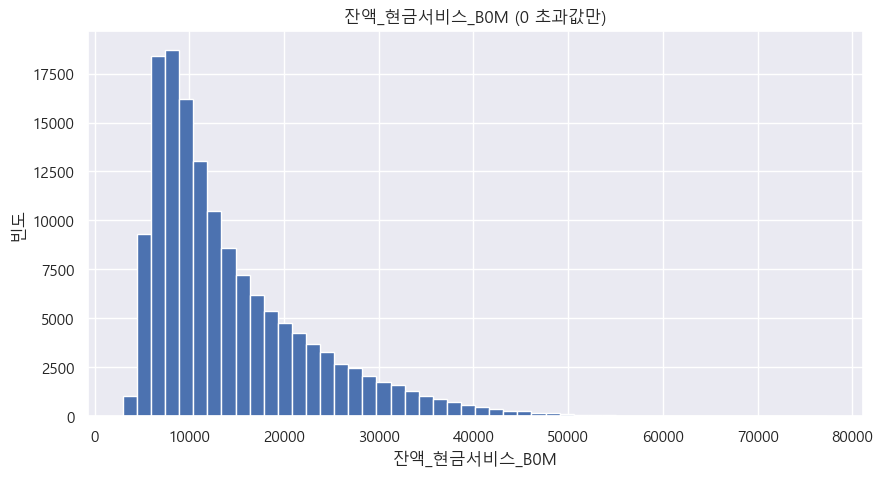

In [594]:
used = all_df[all_df['잔액_현금서비스_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_현금서비스_B0M'],
    bins=50,
)
plt.title('잔액_현금서비스_B0M (0 초과값만)')
plt.xlabel('잔액_현금서비스_B0M')
plt.ylabel('빈도')
plt.show()


### 잔액_리볼빙일시불이월_B0M

In [87]:
all_df['잔액_리볼빙일시불이월_B0M'].value_counts()

잔액_리볼빙일시불이월_B0M
0        2917201
10752         18
11149         17
13431         17
8882          17
          ...   
23194          1
23789          1
22407          1
24526          1
22906          1
Name: count, Length: 17466, dtype: int64

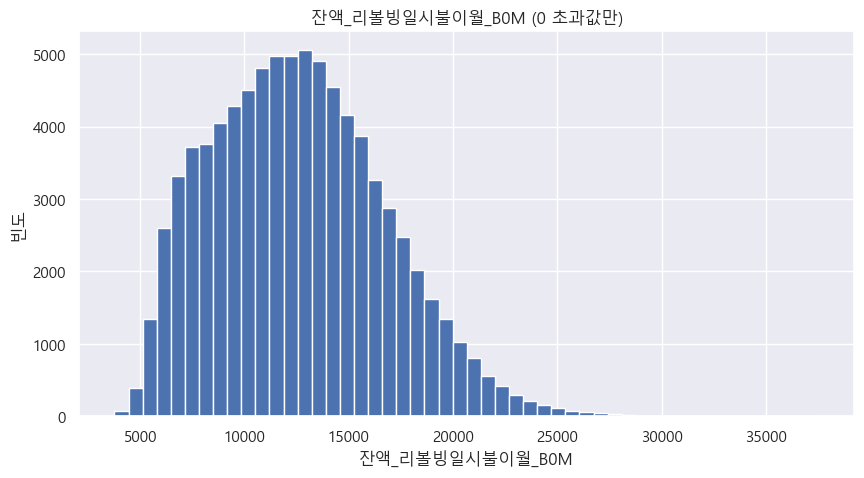

In [596]:
used = all_df[all_df['잔액_리볼빙일시불이월_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_리볼빙일시불이월_B0M'],
    bins=50,
)
plt.title('잔액_리볼빙일시불이월_B0M (0 초과값만)')
plt.xlabel('잔액_리볼빙일시불이월_B0M')
plt.ylabel('빈도')
plt.show()


### 잔액_리볼빙CA이월_B0M

In [92]:
all_df['잔액_리볼빙CA이월_B0M'].value_counts()

잔액_리볼빙CA이월_B0M
0        2998789
5873           6
5866           5
5872           5
5858           5
          ...   
27464          1
27137          1
5939           1
26435          1
10436          1
Name: count, Length: 950, dtype: int64

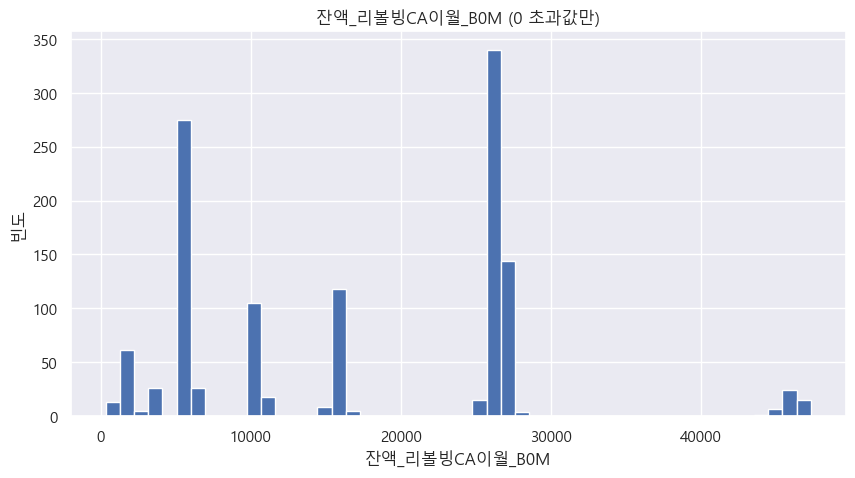

In [598]:
used = all_df[all_df['잔액_리볼빙CA이월_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_리볼빙CA이월_B0M'],
    bins=50,
)
plt.title('잔액_리볼빙CA이월_B0M (0 초과값만)')
plt.xlabel('잔액_리볼빙CA이월_B0M')
plt.ylabel('빈도')
plt.show()


### 잔액_카드론_B0M

In [97]:
all_df['잔액_카드론_B0M'].value_counts()

잔액_카드론_B0M
0         2817523
15573          14
20302          13
14058          13
20021          13
           ...   
59295           1
192518          1
84938           1
29980           1
112441          1
Name: count, Length: 71953, dtype: int64

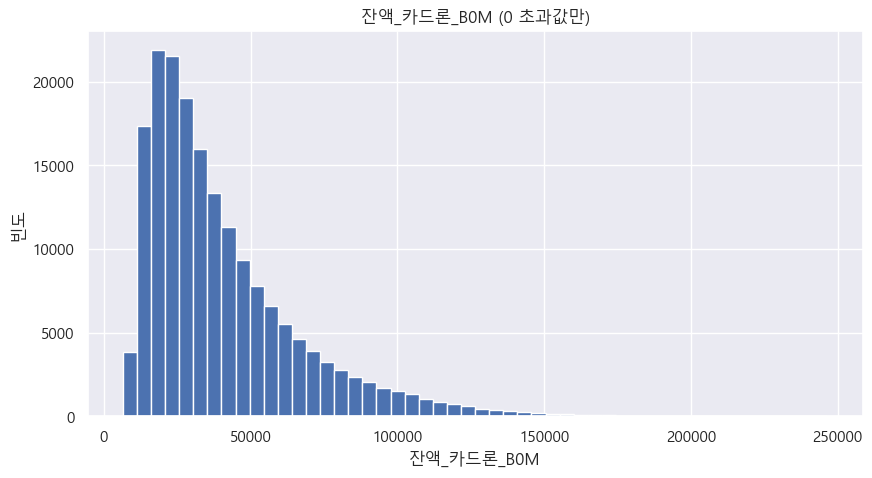

In [600]:
used = all_df[all_df['잔액_카드론_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_카드론_B0M'],
    bins=50,
)
plt.title('잔액_카드론_B0M (0 초과값만)')
plt.xlabel('잔액_카드론_B0M')
plt.ylabel('빈도')
plt.show()


---

## 월중평잔
### 월중평잔_일시불_B0M
- 월 평균 잔액

In [104]:
all_df['월중평잔_일시불_B0M'].value_counts()

월중평잔_일시불_B0M
0        833823
7          1919
8          1885
9          1608
10         1239
          ...  
73065         1
36497         1
56219         1
57807         1
49831         1
Name: count, Length: 53212, dtype: int64

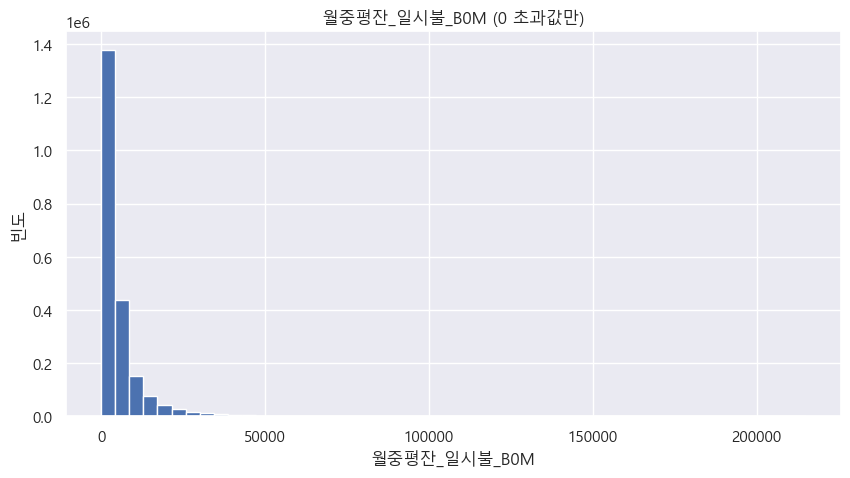

In [602]:
used = all_df[all_df['월중평잔_일시불_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_일시불_B0M'],
    bins=50,
)
plt.title('월중평잔_일시불_B0M (0 초과값만)')
plt.xlabel('월중평잔_일시불_B0M')
plt.ylabel('빈도')
plt.show()


### 월중평잔_할부_B0M

In [107]:
all_df['월중평잔_할부_B0M'].value_counts()

월중평잔_할부_B0M
0        1954749
1428         401
1155         394
1192         394
1074         393
          ...   
28708          1
23548          1
26763          1
63079          1
45745          1
Name: count, Length: 43675, dtype: int64

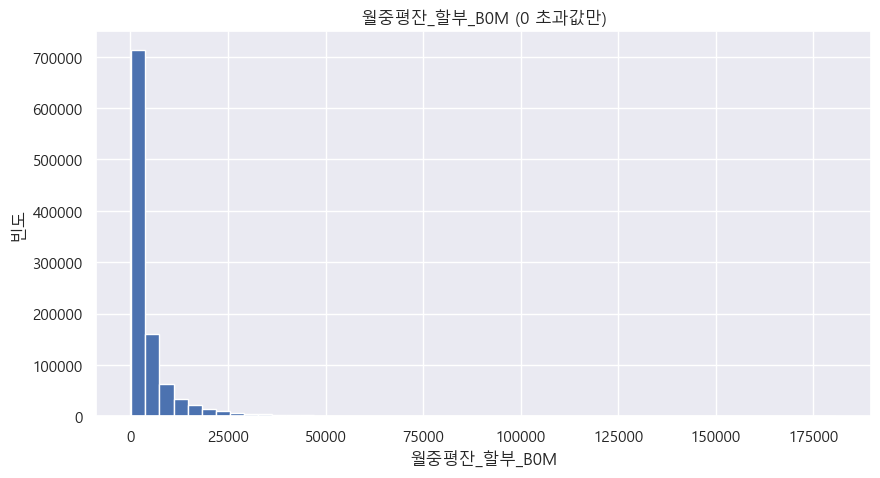

In [604]:
used = all_df[all_df['월중평잔_할부_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_할부_B0M'],
    bins=50,
)
plt.title('월중평잔_할부_B0M (0 초과값만)')
plt.xlabel('월중평잔_할부_B0M')
plt.ylabel('빈도')
plt.show()


### 월중평잔_CA_B0M

In [115]:
all_df['월중평잔_CA_B0M'].value_counts()

월중평잔_CA_B0M
0        2819196
3920          37
3237          36
3291          36
3438          36
          ...   
16085          1
43784          1
19505          1
43959          1
62242          1
Name: count, Length: 38162, dtype: int64

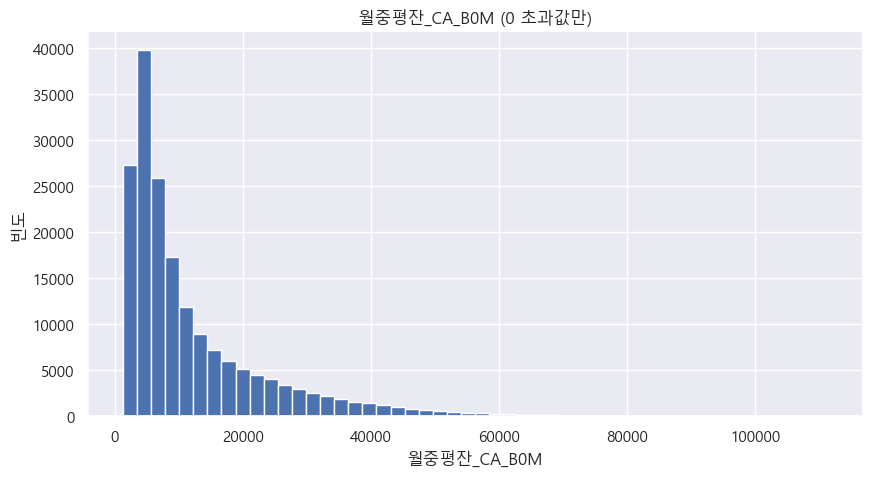

In [606]:
used = all_df[all_df['월중평잔_CA_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_CA_B0M'],
    bins=50,
)
plt.title('월중평잔_CA_B0M (0 초과값만)')
plt.xlabel('월중평잔_CA_B0M')
plt.ylabel('빈도')
plt.show()


---

### 카드론잔액_최종경과월

In [122]:
all_df['카드론잔액_최종경과월'].value_counts()

카드론잔액_최종경과월
0    3000000
Name: count, dtype: int64

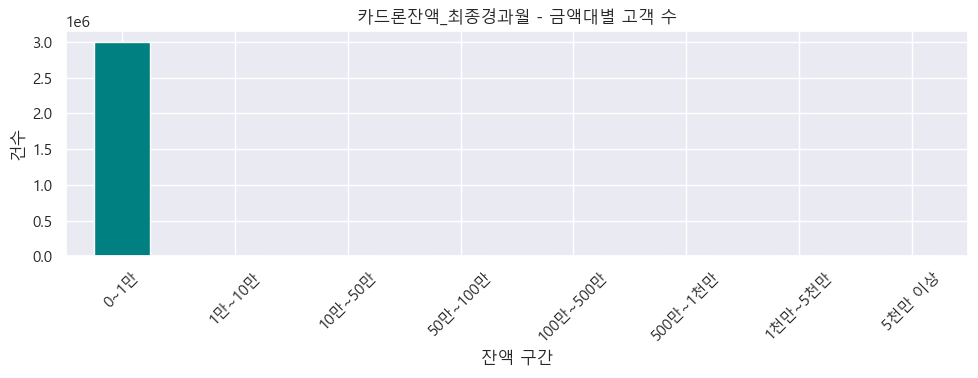

In [215]:
target_col = '카드론잔액_최종경과월'  # 예시: 잔액_카드론_B0M, 평잔_일시불_6M 등등

# 구간 정의
bins = [0, 10000, 100000, 500000, 1000000, 5000000, 10000000, 50000000, 1e9]
labels = ['0~1만', '1만~10만', '10만~50만', '50만~100만',
          '100만~500만', '500만~1천만', '1천만~5천만', '5천만 이상']

# 구간화 + 빈도 계산
binned = pd.cut(all_df[target_col], bins=bins, labels=labels, include_lowest=True)
binned_counts = binned.value_counts().sort_index()

# 시각화
plt.figure(figsize=(10, 4))
binned_counts.plot(kind='bar', color='teal')
plt.title(f'{target_col} - 금액대별 고객 수')
plt.xlabel('잔액 구간')
plt.ylabel('건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

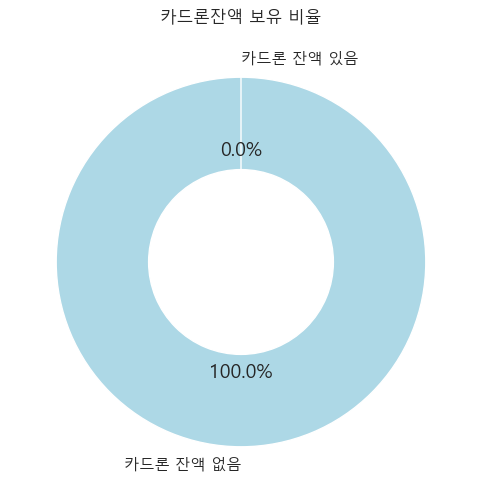

In [131]:
# 변수 정의
count_zero = (all_df['카드론잔액_최종경과월'] == 0).sum()
count_nonzero = (all_df['카드론잔액_최종경과월'] != 0).sum()

# 파이차트
labels = ['카드론 잔액 없음', '카드론 잔액 있음']
sizes = [count_zero, count_nonzero]
colors = ['lightblue', 'lightcoral']

fig, ax = plt.subplots()
ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.5)  # 파이차트 만드는 옵션
)
ax.set_title('카드론잔액 보유 비율')
plt.show()

---

## 연체

### 연체일자_B0M

In [190]:
all_df['연체일자_B0M'].value_counts()

연체일자_B0M
20180521.0    105
20180517.0    104
20180520.0     98
20180523.0     97
20180522.0     91
             ... 
20180407.0      2
20181024.0      2
20181023.0      2
20181026.0      1
20181022.0      1
Name: count, Length: 201, dtype: int64

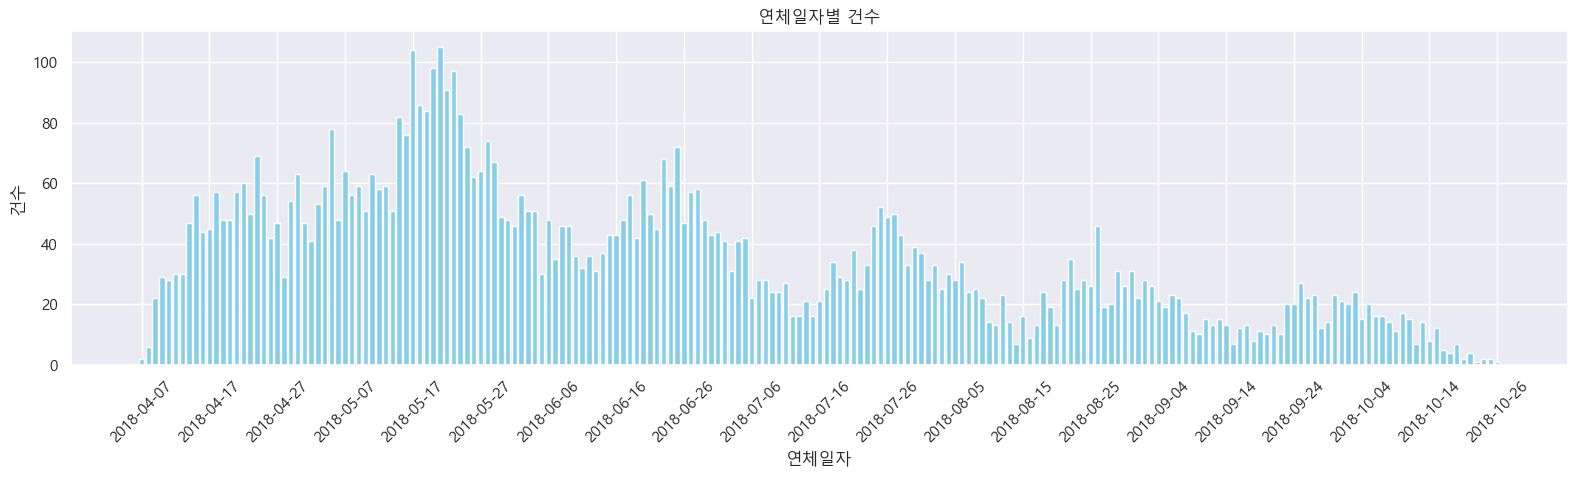

In [198]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜 변환 & 집계
dates = pd.to_datetime(all_df['연체일자_B0M'], format='%Y%m%d', errors='coerce')
date_counts = dates.value_counts().sort_index()

# x축 간격 조절용: 10일 단위만 라벨 표시
tick_interval = 10
tick_positions = range(0, len(date_counts), tick_interval)
tick_labels = date_counts.index.strftime('%Y-%m-%d')[::tick_interval]

# 시각화
plt.figure(figsize=(16, 5))
plt.bar(range(len(date_counts)), date_counts.values, color='skyblue')
plt.title('연체일자별 건수')
plt.xlabel('연체일자')
plt.ylabel('건수')
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45)
plt.tight_layout()
plt.show()

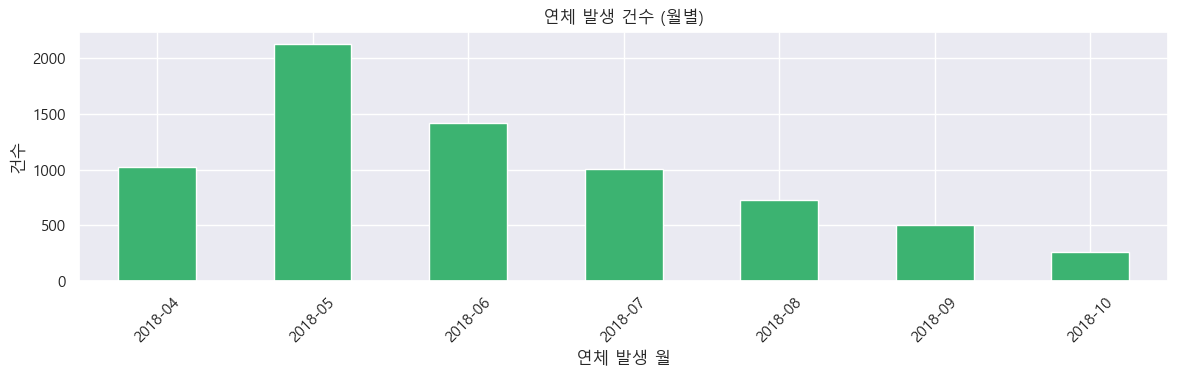

In [162]:
# 1. 날짜 변환
dates = pd.to_datetime(all_df['연체일자_B0M'], format='%Y%m%d', errors='coerce')

# ✅ 2. NaT 제거
dates = dates.dropna()

# 3. 월 단위 변환
months = dates.dt.to_period('M').astype(str)

# 4. 월별 집계
month_counts = months.value_counts().sort_index()

# 5. 시각화
plt.figure(figsize=(12, 4))
month_counts.plot(kind='bar', color='mediumseagreen')
plt.title('연체 발생 건수 (월별)')
plt.xlabel('연체 발생 월')
plt.ylabel('건수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [188]:
# 1. 연체일자가 존재하는 행만 필터링 (0 또는 NaN이 아닌 값)
filtered_df = all_df[all_df['연체일자_B0M'].notna() & (all_df['연체일자_B0M'] != 0)]

# 2. ID별 연체일자만 출력 (중복 제거해서 보기 좋게)
result = filtered_df[['ID', '연체일자_B0M']].drop_duplicates().sort_values(by=['ID', '연체일자_B0M'])

# 3. 미리보기
result

,ID,연체일자_B0M
2400282,TEST_00282,20180425.0
2500282,TEST_00282,20180522.0
2600282,TEST_00282,20180622.0
2700282,TEST_00282,20180719.0
2400310,TEST_00310,20180504.0
...,...,...
399789,TRAIN_399789,20180505.0
399845,TRAIN_399845,20180416.0
799845,TRAIN_399845,20180518.0
399902,TRAIN_399902,20180424.0


In [207]:
# 연체일자 있는 행만 필터링
filtered_df = all_df[all_df['연체일자_B0M'].notna() & (all_df['연체일자_B0M'] != 0)]

# 그룹화: ID별 연체일자 리스트 + 연체 횟수
grouped_df = (
    filtered_df[['ID', '연체일자_B0M']]
    .drop_duplicates()
    .sort_values(by=['ID', '연체일자_B0M'])
    .groupby('ID')['연체일자_B0M']
    .agg(['count', list])  # 연체 횟수, 연체일자 리스트
    .reset_index()
    .rename(columns={'count': '연체건수', 'list': '연체일자목록'})
)

# 미리보기
grouped_df.head(10)

,ID,연체건수,연체일자목록
0,TEST_00282,4,"[20180425.0, 20180522.0, 20180622.0, 20180719.0]"
1,TEST_00310,3,"[20180504.0, 20180526.0, 20180627.0]"
2,TEST_00409,3,"[20180422.0, 20180520.0, 20180622.0]"
3,TEST_00456,6,"[20180521.0, 20180609.0, 20180703.0, 20180730...."
4,TEST_00469,3,"[20180429.0, 20180527.0, 20180624.0]"
5,TEST_00790,3,"[20180506.0, 20180603.0, 20180701.0]"
6,TEST_01005,5,"[20180419.0, 20180515.0, 20180618.0, 20180715...."
7,TEST_01104,1,[20180505.0]
8,TEST_01267,3,"[20180415.0, 20180518.0, 20180615.0]"
9,TEST_01413,1,[20180510.0]


### 연체잔액_B0M

In [222]:
all_df['연체잔액_B0M'].value_counts()

연체잔액_B0M
0        2995567
3737           7
3766           7
1260           7
3681           7
          ...   
20439          1
17737          1
20549          1
13987          1
2079           1
Name: count, Length: 2510, dtype: int64

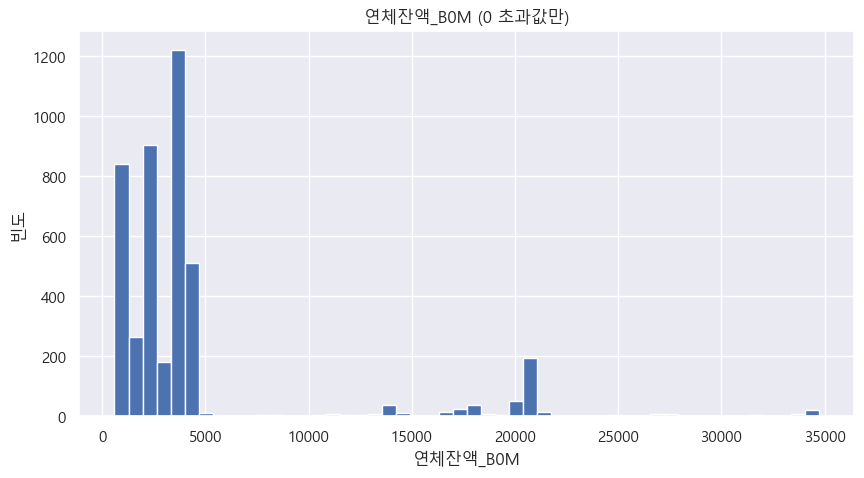

In [608]:
used = all_df[all_df['연체잔액_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_B0M'],
    bins=50,
)
plt.title('연체잔액_B0M (0 초과값만)')
plt.xlabel('연체잔액_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_일시불_B0M

In [224]:
all_df['연체잔액_일시불_B0M'].value_counts()

연체잔액_일시불_B0M
0       2996561
1446         13
1308         12
1352         12
1181         12
         ...   
1493          1
871           1
1786          1
851           1
649           1
Name: count, Length: 947, dtype: int64

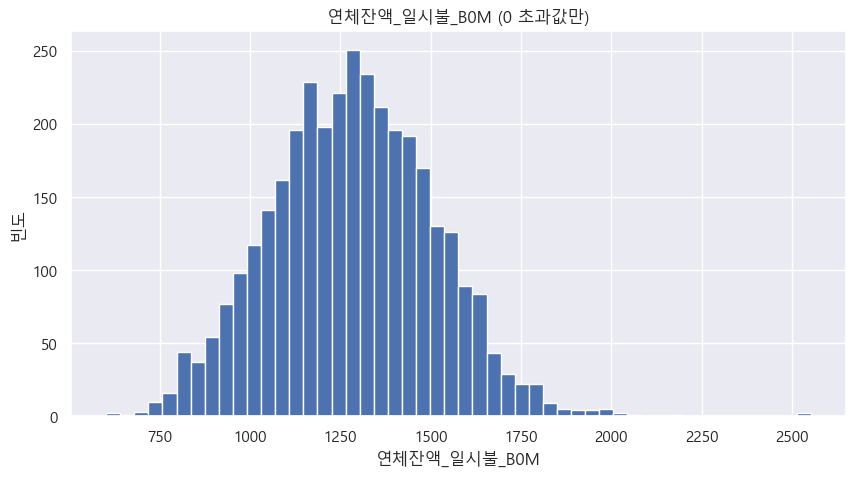

In [610]:
used = all_df[all_df['연체잔액_일시불_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_일시불_B0M'],
    bins=50,
)
plt.title('연체잔액_일시불_B0M (0 초과값만)')
plt.xlabel('연체잔액_일시불_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_할부_B0M

In [612]:
all_df['연체잔액_할부_B0M'].value_counts()

연체잔액_할부_B0M
0       2996709
2288         12
2430         11
2426         11
2460         11
         ...   
2793          1
2148          1
2191          1
2838          1
2079          1
Name: count, Length: 882, dtype: int64

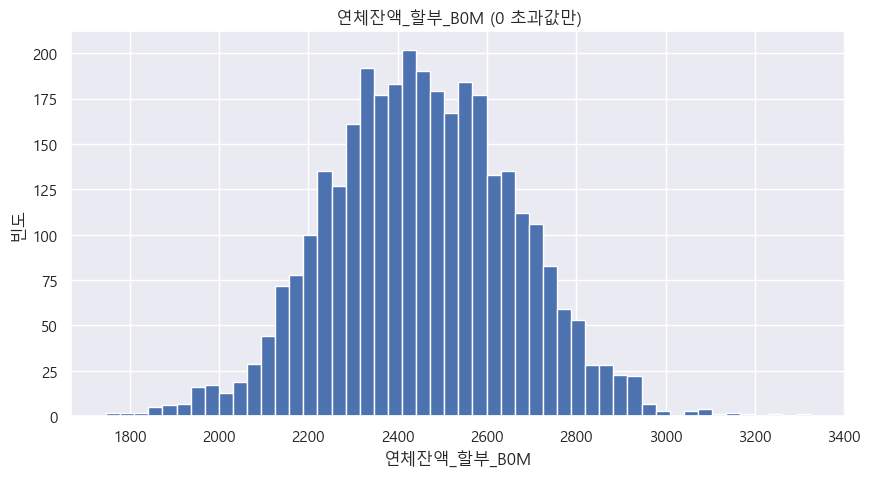

In [614]:
used = all_df[all_df['연체잔액_할부_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_할부_B0M'],
    bins=50,
)
plt.title('연체잔액_할부_B0M (0 초과값만)')
plt.xlabel('연체잔액_할부_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_현금서비스_B0M

In [248]:
all_df['연체잔액_현금서비스_B0M'].value_counts()

연체잔액_현금서비스_B0M
0        2999566
16440          6
16378          6
16422          5
16374          5
          ...   
16405          1
16316          1
16414          1
16356          1
16334          1
Name: count, Length: 298, dtype: int64

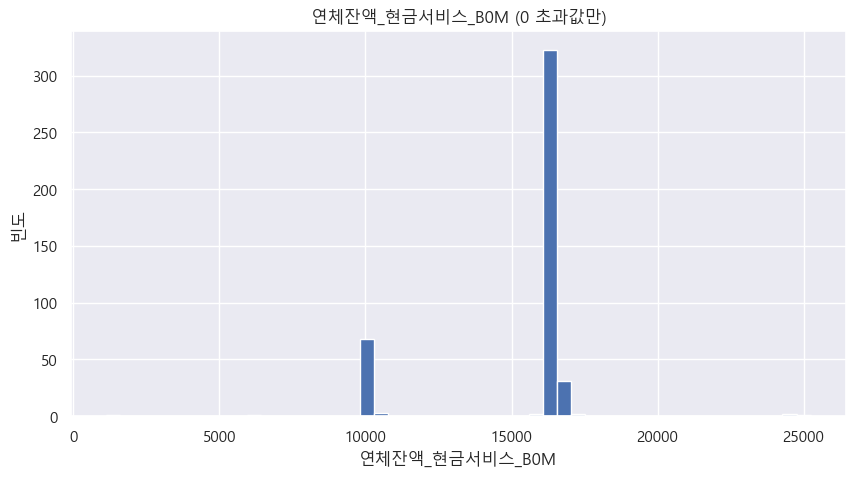

In [246]:
used = all_df[all_df['연체잔액_현금서비스_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_현금서비스_B0M'],
    bins=50,
)
plt.title('연체잔액_현금서비스_B0M (0 초과값만)')
plt.xlabel('연체잔액_현금서비스_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_카드론_B0M

In [252]:
all_df['연체잔액_카드론_B0M'].value_counts()

연체잔액_현금서비스_B0M
0        2999566
16440          6
16378          6
16422          5
16374          5
          ...   
16405          1
16316          1
16414          1
16356          1
16334          1
Name: count, Length: 298, dtype: int64

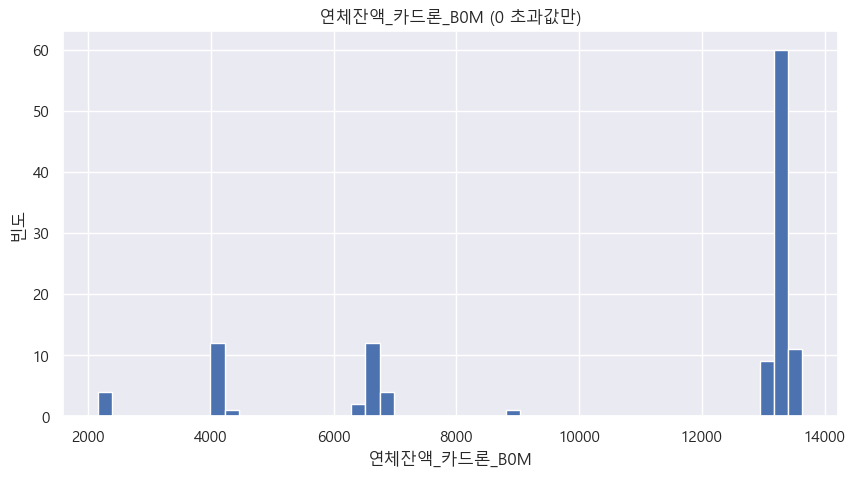

In [254]:
used = all_df[all_df['연체잔액_카드론_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_카드론_B0M'],
    bins=50,
)
plt.title('연체잔액_카드론_B0M (0 초과값만)')
plt.xlabel('연체잔액_카드론_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_대환론_B0M

In [259]:
all_df['연체잔액_대환론_B0M'].value_counts()

연체잔액_대환론_B0M
0        2999994
27479          1
27348          1
27752          1
27018          1
27108          1
27663          1
Name: count, dtype: int64

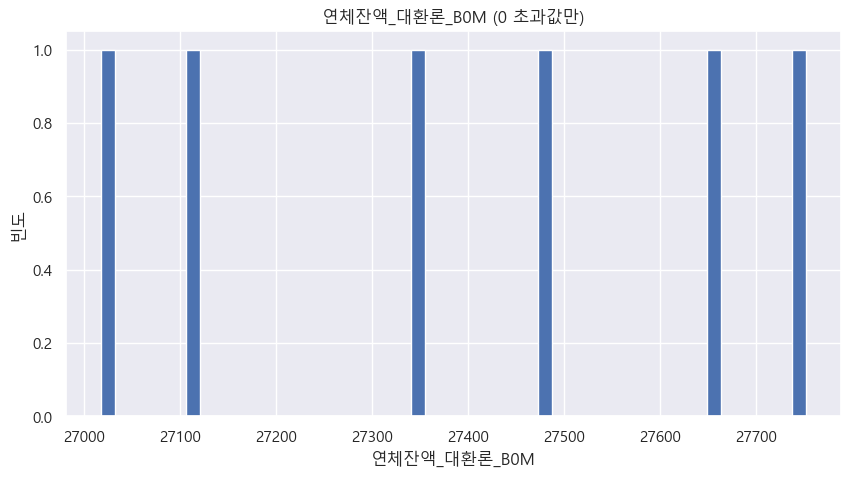

In [257]:
used = all_df[all_df['연체잔액_대환론_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_대환론_B0M'],
    bins=50,
)
plt.title('연체잔액_대환론_B0M (0 초과값만)')
plt.xlabel('연체잔액_대환론_B0M')
plt.ylabel('빈도')
plt.show()

---

## 잔액

### 잔액_현금서비스_B1M

In [262]:
all_df['잔액_현금서비스_B1M'].value_counts()

잔액_현금서비스_B1M
0        2843057
6861          30
5541          28
6825          27
5659          27
          ...   
37774          1
45999          1
26991          1
40812          1
49336          1
Name: count, Length: 37720, dtype: int64

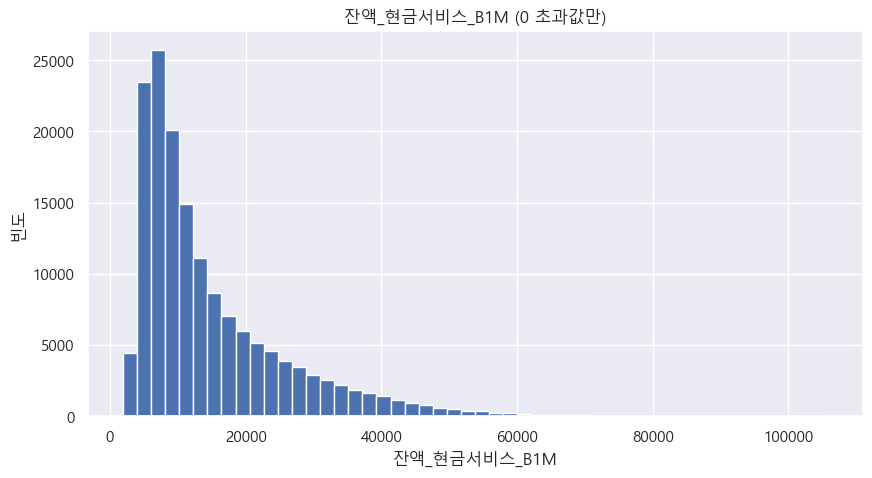

In [264]:
used = all_df[all_df['잔액_현금서비스_B1M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_현금서비스_B1M'],
    bins=50,
)
plt.title('잔액_현금서비스_B1M (0 초과값만)')
plt.xlabel('잔액_현금서비스_B1M')
plt.ylabel('빈도')
plt.show()

### 잔액_현금서비스_B2M

In [268]:
all_df['잔액_현금서비스_B2M'].value_counts()

잔액_현금서비스_B2M
0        2840001
6861          28
5541          27
6526          26
6490          26
          ...   
19704          1
15575          1
16655          1
34063          1
68575          1
Name: count, Length: 37427, dtype: int64

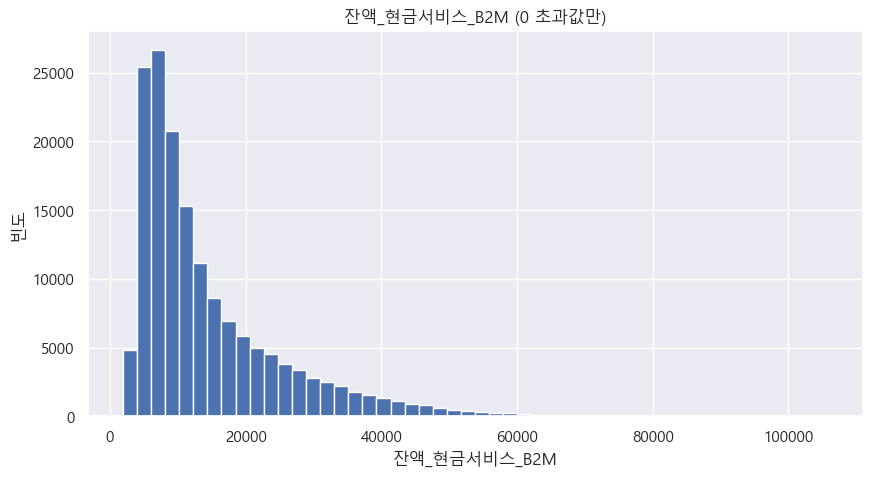

In [270]:
used = all_df[all_df['잔액_현금서비스_B2M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_현금서비스_B2M'],
    bins=50,
)
plt.title('잔액_현금서비스_B2M (0 초과값만)')
plt.xlabel('잔액_현금서비스_B2M')
plt.ylabel('빈도')
plt.show()

### 잔액_카드론_B1M

In [273]:
all_df['잔액_카드론_B1M'].value_counts()

잔액_카드론_B1M
0         2815387
244906         23
15549          14
17494          14
15656          14
           ...   
70839           1
132874          1
61457           1
88011           1
119855          1
Name: count, Length: 77167, dtype: int64

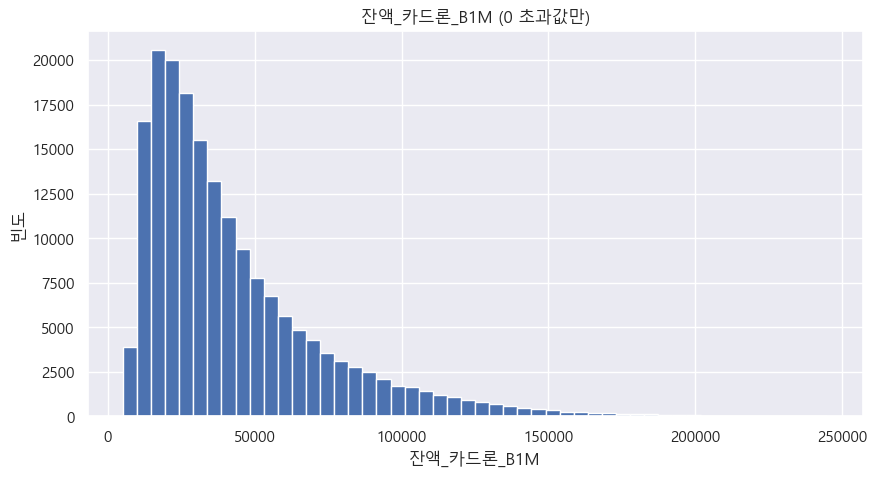

In [275]:
used = all_df[all_df['잔액_카드론_B1M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_카드론_B1M'],
    bins=50,
)
plt.title('잔액_카드론_B1M (0 초과값만)')
plt.xlabel('잔액_카드론_B1M')
plt.ylabel('빈도')
plt.show()

### 잔액_카드론_B2M

In [278]:
all_df['잔액_카드론_B2M'].value_counts()

잔액_카드론_B2M
0         2813529
244906         18
15656          15
23701          14
19334          14
           ...   
51115           1
199910          1
156940          1
85786           1
110940          1
Name: count, Length: 77912, dtype: int64

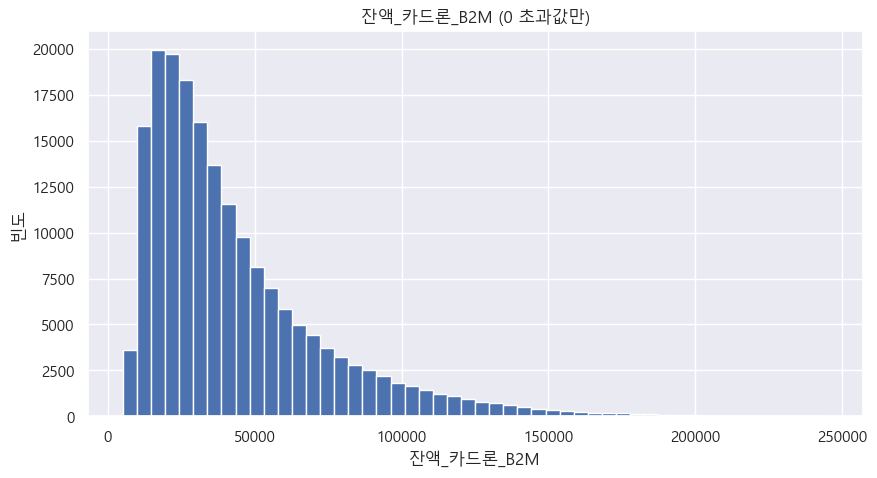

In [280]:
used = all_df[all_df['잔액_카드론_B2M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_카드론_B2M'],
    bins=50,
)
plt.title('잔액_카드론_B2M (0 초과값만)')
plt.xlabel('잔액_카드론_B2M')
plt.ylabel('빈도')
plt.show()

### 잔액_카드론_B3M

In [285]:
all_df['잔액_카드론_B3M'].value_counts()

잔액_카드론_B3M
0         2812519
230000         16
16179          13
25240          12
34389          12
           ...   
126442          1
86108           1
52067           1
107162          1
109568          1
Name: count, Length: 78299, dtype: int64

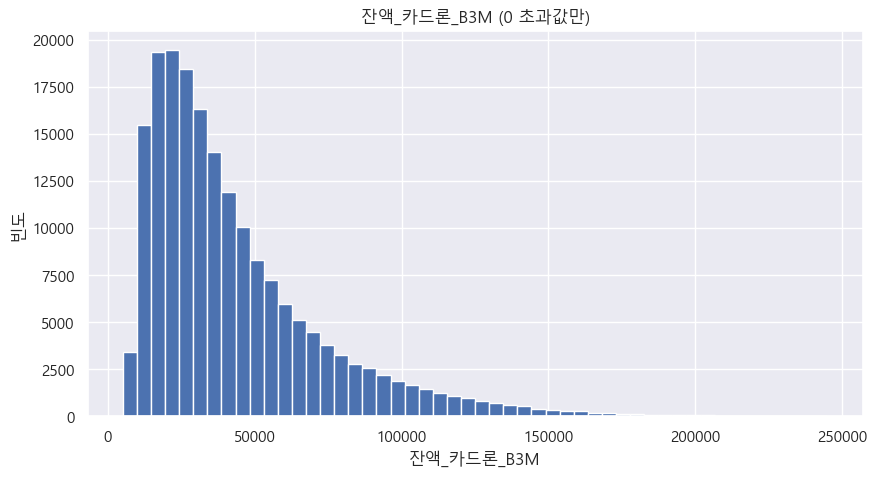

In [287]:
used = all_df[all_df['잔액_카드론_B3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_카드론_B3M'],
    bins=50,
)
plt.title('잔액_카드론_B3M (0 초과값만)')
plt.xlabel('잔액_카드론_B3M')
plt.ylabel('빈도')
plt.show()

### 잔액_카드론_B4M

In [290]:
all_df['잔액_카드론_B4M'].value_counts()

잔액_카드론_B4M
0         2811138
230000         23
25851          13
25388          13
16179          13
           ...   
77802           1
80924           1
64906           1
68946           1
109613          1
Name: count, Length: 78385, dtype: int64

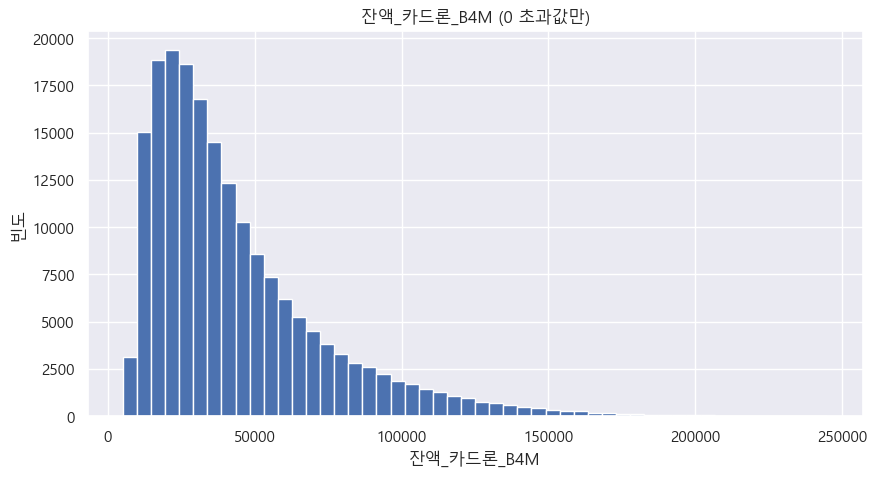

In [292]:
used = all_df[all_df['잔액_카드론_B4M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_카드론_B4M'],
    bins=50,
)
plt.title('잔액_카드론_B4M (0 초과값만)')
plt.xlabel('잔액_카드론_B4M')
plt.ylabel('빈도')
plt.show()

### 잔액_카드론_B5M

In [295]:
all_df['잔액_카드론_B5M'].value_counts()

잔액_카드론_B5M
0         2805949
230000         26
21809          15
20989          14
24000          13
           ...   
66144           1
116088          1
35131           1
70975           1
130760          1
Name: count, Length: 79328, dtype: int64

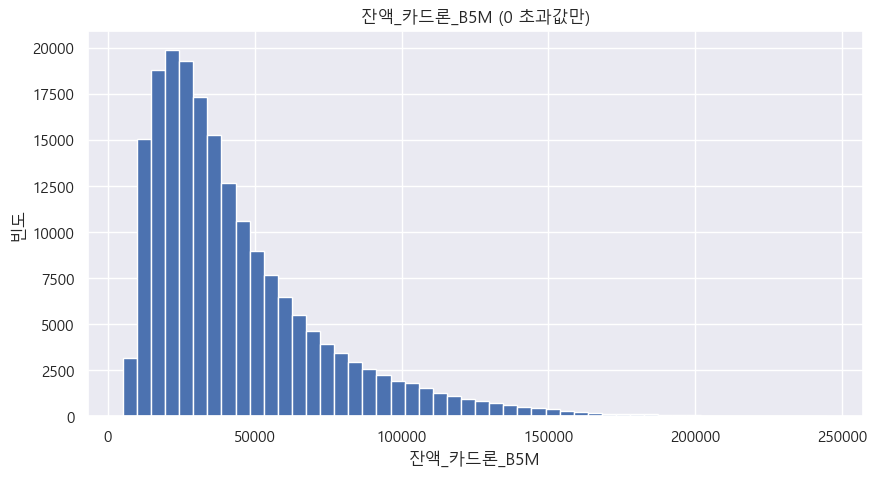

In [297]:
used = all_df[all_df['잔액_카드론_B5M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_카드론_B5M'],
    bins=50,
)
plt.title('잔액_카드론_B5M (0 초과값만)')
plt.xlabel('잔액_카드론_B5M')
plt.ylabel('빈도')
plt.show()

### 잔액_할부_B1M

In [300]:
all_df['잔액_할부_B1M'].value_counts()

잔액_할부_B1M
0        1983744
1291         371
1220         366
1065         364
1357         363
          ...   
61183          1
99406          1
22806          1
44010          1
26575          1
Name: count, Length: 45434, dtype: int64

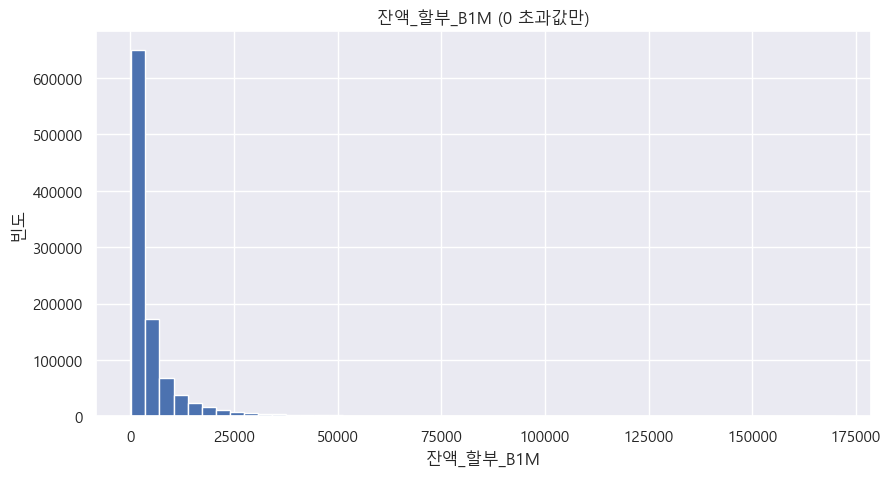

In [302]:
used = all_df[all_df['잔액_할부_B1M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_할부_B1M'],
    bins=50,
)
plt.title('잔액_할부_B1M (0 초과값만)')
plt.xlabel('잔액_할부_B1M')
plt.ylabel('빈도')
plt.show()

### 잔액_할부_B2M

In [305]:
all_df['잔액_할부_B2M'].value_counts()

잔액_할부_B2M
0        1970178
1220         353
1203         350
1338         349
1291         348
          ...   
55308          1
40427          1
33828          1
53568          1
80055          1
Name: count, Length: 47595, dtype: int64

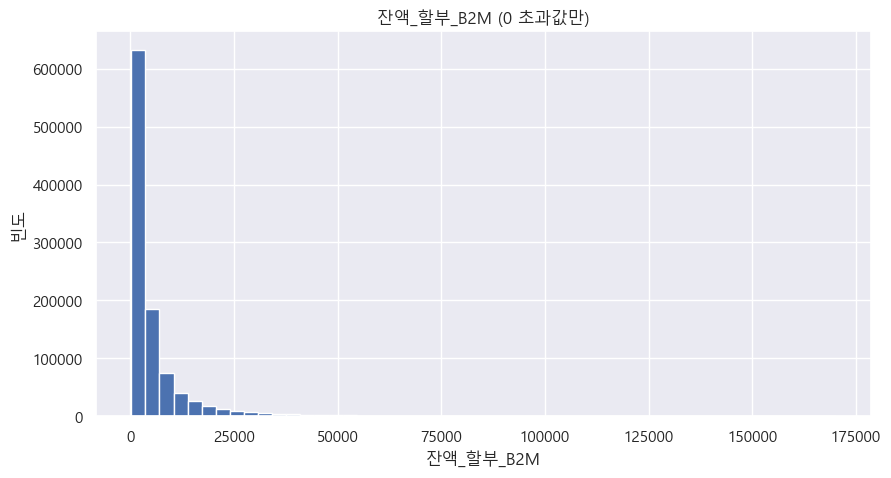

In [307]:
used = all_df[all_df['잔액_할부_B2M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_할부_B2M'],
    bins=50,
)
plt.title('잔액_할부_B2M (0 초과값만)')
plt.xlabel('잔액_할부_B2M')
plt.ylabel('빈도')
plt.show()

### 잔액_일시불_B1M

In [310]:
all_df['잔액_일시불_B1M'].value_counts()

잔액_일시불_B1M
0         858129
8           1832
9           1744
6           1744
7           1722
           ...  
112477         1
70801          1
65789          1
39141          1
73863          1
Name: count, Length: 55242, dtype: int64

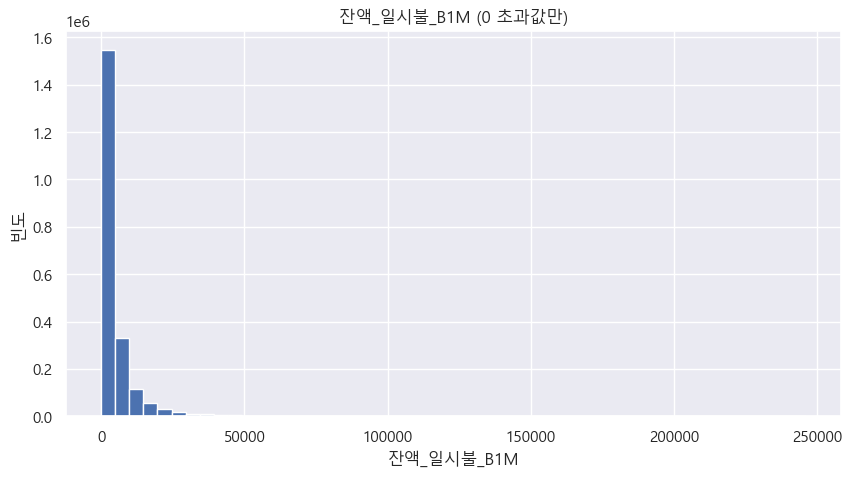

In [312]:
used = all_df[all_df['잔액_일시불_B1M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_일시불_B1M'],
    bins=50,
)
plt.title('잔액_일시불_B1M (0 초과값만)')
plt.xlabel('잔액_일시불_B1M')
plt.ylabel('빈도')
plt.show()

### 잔액_일시불_B2M

In [315]:
all_df['잔액_일시불_B2M'].value_counts()

잔액_일시불_B2M
0        864147
6          1729
7          1651
8          1651
9          1506
          ...  
61855         1
66095         1
89825         1
35318         1
56805         1
Name: count, Length: 55070, dtype: int64

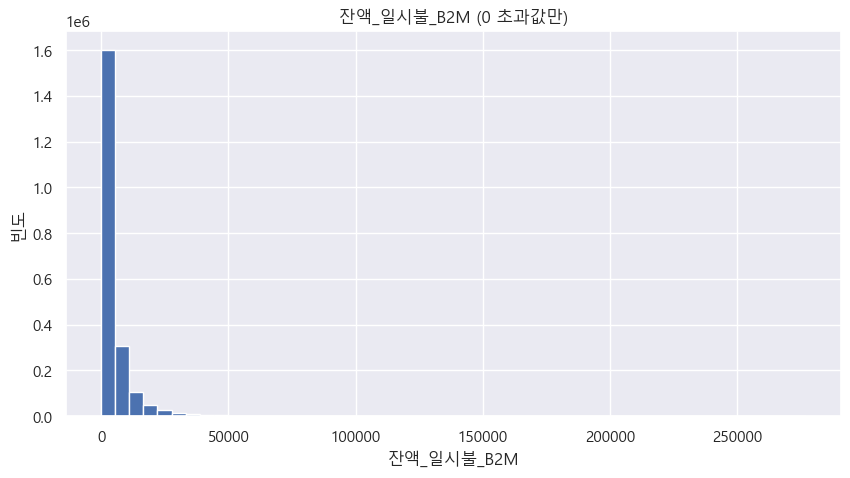

In [317]:
used = all_df[all_df['잔액_일시불_B2M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_일시불_B2M'],
    bins=50,
)
plt.title('잔액_일시불_B2M (0 초과값만)')
plt.xlabel('잔액_일시불_B2M')
plt.ylabel('빈도')
plt.show()

---

## 연체일수

### 연체일수_B1M

In [672]:
all_df['연체일수_B1M'].value_counts() # 결측치 처리해야함.

연체일수_B1M
-999999    2650810
 0          347800
 1            1390
Name: count, dtype: int64

### 연체일수_B2M

In [618]:
all_df['연체일수_B2M'].value_counts() # 결측치 처리해야함.

연체일수_B2M
-999999    2637352
 0          361342
 1            1306
Name: count, dtype: int64

### 연체원금_B1M

In [332]:
all_df['연체원금_B1M'].value_counts()

연체원금_B1M
0        2985633
1068          12
860           11
1174          11
1041          10
          ...   
7088           1
10538          1
5656           1
2210           1
6492           1
Name: count, Length: 6962, dtype: int64

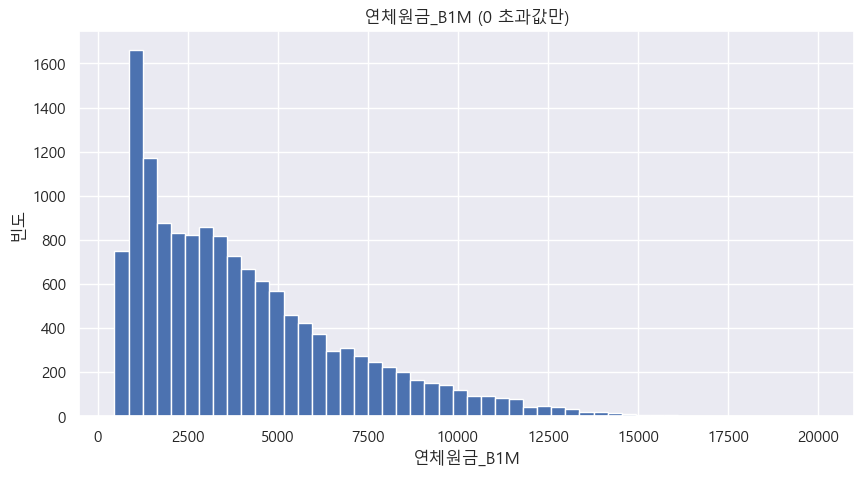

In [334]:
used = all_df[all_df['연체원금_B1M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체원금_B1M'],
    bins=50,
)
plt.title('연체원금_B1M (0 초과값만)')
plt.xlabel('연체원금_B1M')
plt.ylabel('빈도')
plt.show()

### 연체원금_B2M

In [338]:
all_df['연체원금_B2M'].value_counts()

연체원금_B2M
0       2983822
1068         12
860          11
2739         11
1174         10
         ...   
6285          1
8849          1
5178          1
5129          1
2401          1
Name: count, Length: 7391, dtype: int64

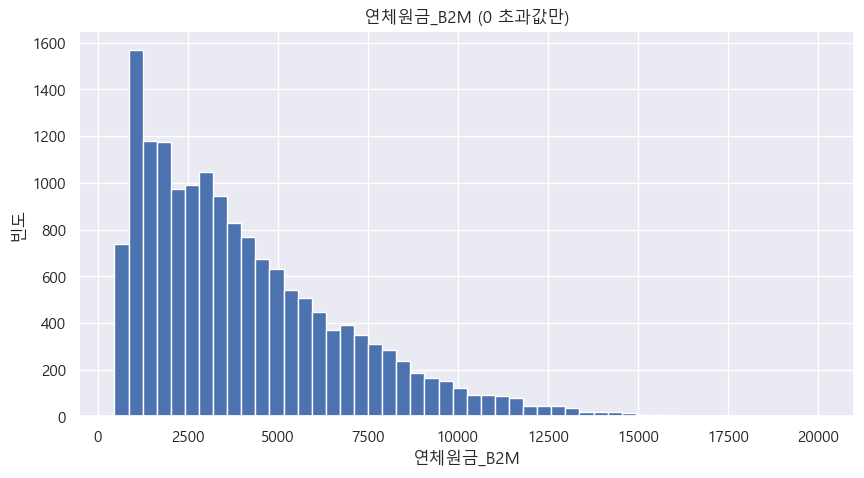

In [336]:
used = all_df[all_df['연체원금_B2M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체원금_B2M'],
    bins=50,
)
plt.title('연체원금_B2M (0 초과값만)')
plt.xlabel('연체원금_B2M')
plt.ylabel('빈도')
plt.show()

### 연체일수_최근

In [620]:
all_df['연체일수_최근'].value_counts() # 결측치 처리해야함.

연체일수_최근
-999999    2952416
 0           43951
 1            3633
Name: count, dtype: int64

### 연체원금_최근

In [622]:
all_df['연체원금_최근'].value_counts()

연체원금_최근
0        2991587
3996           7
3550           7
4495           6
4246           6
          ...   
7267           1
7063           1
12089          1
4956           1
3498           1
Name: count, Length: 4969, dtype: int64

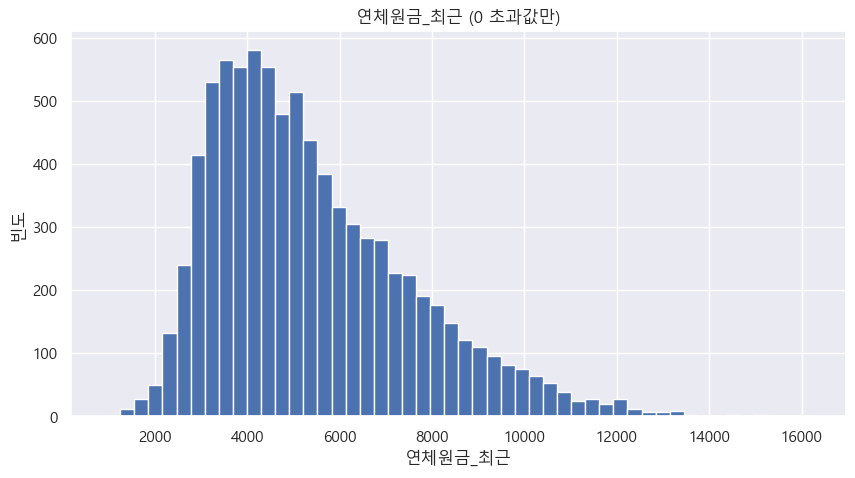

In [630]:
used = all_df[all_df['연체원금_최근'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체원금_최근'],
    bins=50,
)
plt.title('연체원금_최근 (0 초과값만)')
plt.xlabel('연체원금_최근')
plt.ylabel('빈도')
plt.show()

### 최종연체회차

In [624]:
all_df['최종연체회차'].value_counts() # 결측치 처리해야함.

최종연체회차
-99    1996331
 0     1003669
Name: count, dtype: int64

### 매각잔액_B1M

In [343]:
all_df['매각잔액_B1M'].value_counts()

매각잔액_B1M
0        2999999
46708          1
Name: count, dtype: int64

### 최종연체개월수_R15M

In [349]:
all_df['최종연체개월수_R15M'].value_counts()

최종연체개월수_R15M
0    3000000
Name: count, dtype: int64

---

## RV 리볼빙

### RV_평균잔액_R12M

In [354]:
all_df['RV_평균잔액_R12M'].value_counts()

RV_평균잔액_R12M
0        2814822
367          275
343          274
363          273
386          271
          ...   
22265          1
29707          1
16672          1
38569          1
16280          1
Name: count, Length: 33573, dtype: int64

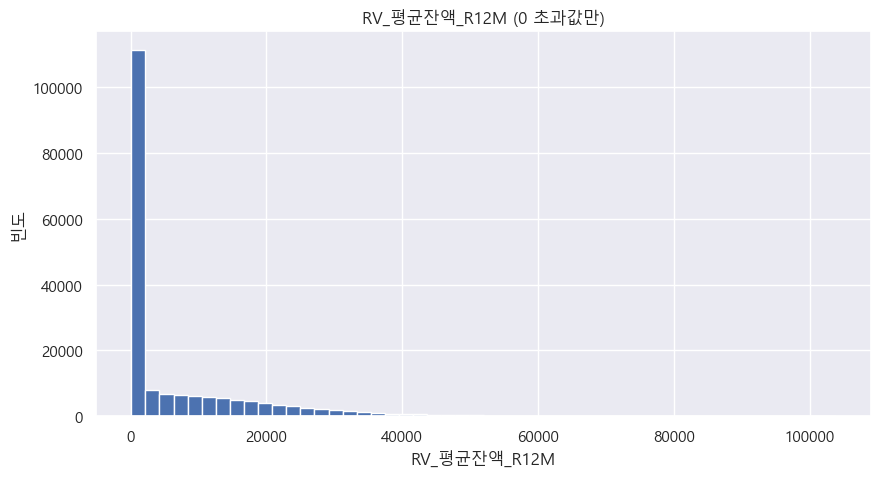

In [626]:
used = all_df[all_df['RV_평균잔액_R12M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['RV_평균잔액_R12M'],
    bins=50,
)
plt.title('RV_평균잔액_R12M (0 초과값만)')
plt.xlabel('RV_평균잔액_R12M')
plt.ylabel('빈도')
plt.show()

### RV_최대잔액_R12M

In [360]:
all_df['RV_최대잔액_R12M'].value_counts()

RV_최대잔액_R12M
0        2814883
2665          85
2503          82
2298          80
2380          79
          ...   
21687          1
19409          1
52012          1
42615          1
46834          1
Name: count, Length: 38609, dtype: int64

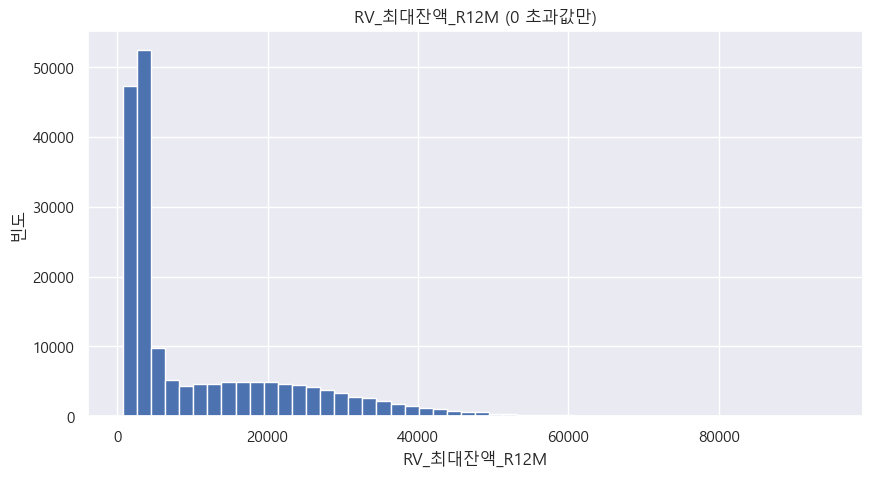

In [380]:
used = all_df[all_df['RV_최대잔액_R12M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['RV_최대잔액_R12M'],
    bins=50,
)
plt.title('RV_최대잔액_R12M (0 초과값만)')
plt.xlabel('RV_최대잔액_R12M')
plt.ylabel('빈도')
plt.show()

### RV_평균잔액_R6M

In [362]:
all_df['RV_평균잔액_R6M'].value_counts()

RV_평균잔액_R6M
0        2865907
708           85
791           84
753           81
731           81
          ...   
27592          1
14790          1
44029          1
33202          1
21858          1
Name: count, Length: 29064, dtype: int64

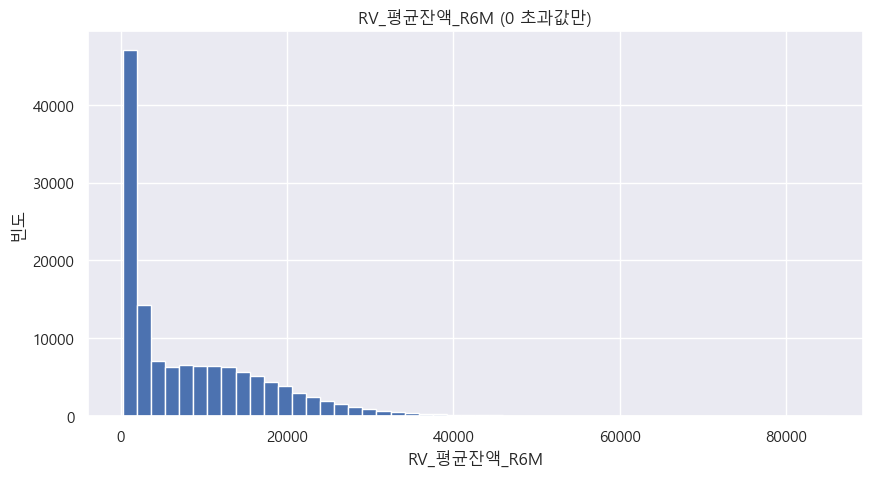

In [383]:
used = all_df[all_df['RV_평균잔액_R6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['RV_평균잔액_R6M'],
    bins=50,
)
plt.title('RV_평균잔액_R6M (0 초과값만)')
plt.xlabel('RV_평균잔액_R6M')
plt.ylabel('빈도')
plt.show()

### RV_최대잔액_R6M

In [364]:
all_df['RV_최대잔액_R6M'].value_counts()

RV_최대잔액_R6M
0        2865804
2661          40
2371          40
2693          37
3778          36
          ...   
28854          1
27452          1
30372          1
21839          1
11050          1
Name: count, Length: 31388, dtype: int64

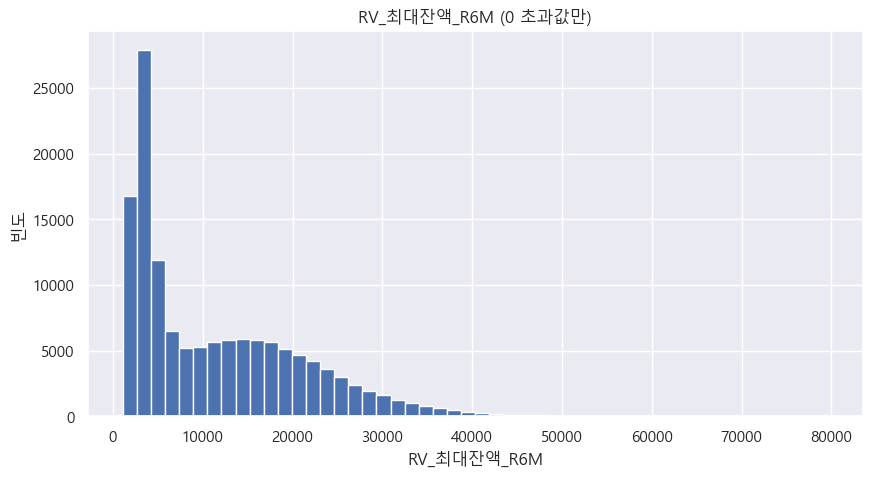

In [385]:
used = all_df[all_df['RV_최대잔액_R6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['RV_최대잔액_R6M'],
    bins=50,
)
plt.title('RV_최대잔액_R6M (0 초과값만)')
plt.xlabel('RV_최대잔액_R6M')
plt.ylabel('빈도')
plt.show()

### RV_평균잔액_R3M

In [366]:
all_df['RV_평균잔액_R3M'].value_counts()

RV_평균잔액_R3M
0        2887721
1763          37
2104          37
1721          36
1809          35
          ...   
27177          1
19618          1
26888          1
17284          1
32809          1
Name: count, Length: 26667, dtype: int64

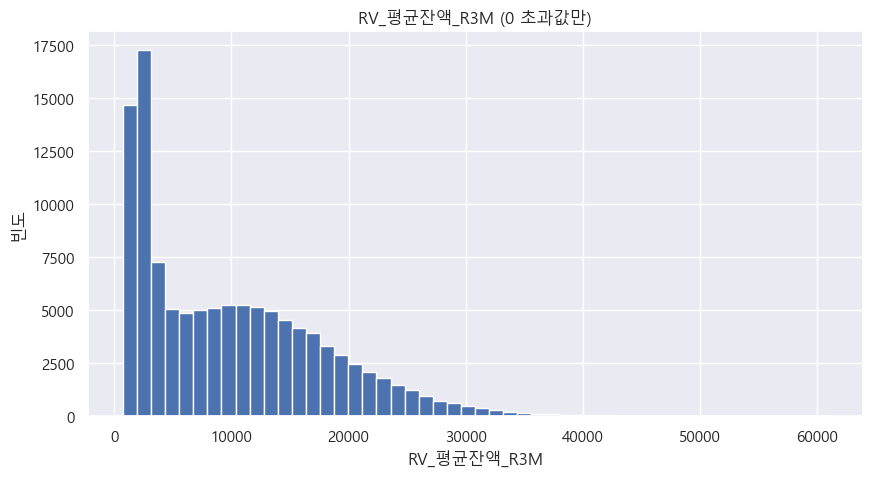

In [387]:
used = all_df[all_df['RV_평균잔액_R3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['RV_평균잔액_R3M'],
    bins=50,
)
plt.title('RV_평균잔액_R3M (0 초과값만)')
plt.xlabel('RV_평균잔액_R3M')
plt.ylabel('빈도')
plt.show()

### RV_최대잔액_R3M

In [368]:
all_df['RV_최대잔액_R3M'].value_counts()

RV_최대잔액_R3M
0        2887472
3778          34
3330          29
3376          26
3429          25
          ...   
33324          1
34483          1
35720          1
32685          1
16846          1
Name: count, Length: 27559, dtype: int64

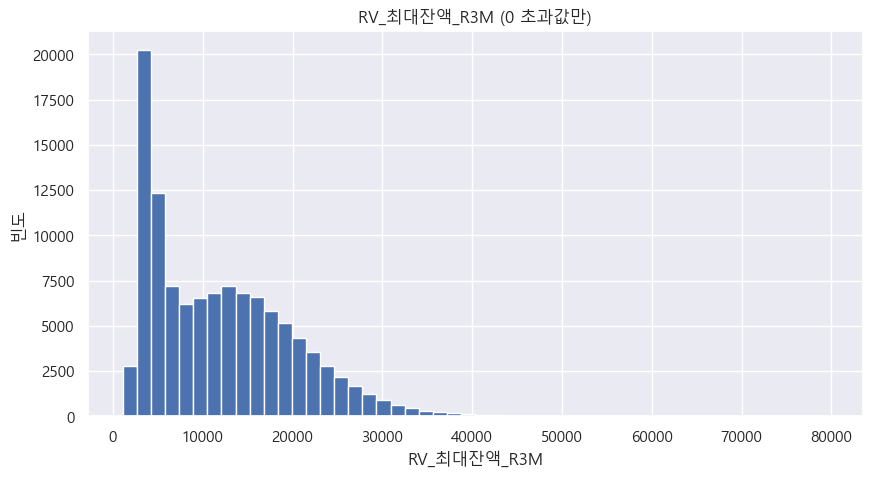

In [389]:
used = all_df[all_df['RV_최대잔액_R3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['RV_최대잔액_R3M'],
    bins=50,
)
plt.title('RV_최대잔액_R3M (0 초과값만)')
plt.xlabel('RV_최대잔액_R3M')
plt.ylabel('빈도')
plt.show()

### RV잔액이월횟수_R6M

In [370]:
all_df['RV잔액이월횟수_R6M'].value_counts()

RV잔액이월횟수_R6M
0    3000000
Name: count, dtype: int64

### RV잔액이월횟수_R3M

In [372]:
all_df['RV잔액이월횟수_R3M'].value_counts()

RV잔액이월횟수_R3M
0    3000000
Name: count, dtype: int64

---

## 잔액할부

### 잔액_할부_유이자_B0M

In [403]:
all_df['잔액_할부_유이자_B0M'].value_counts()

잔액_할부_유이자_B0M
0        2532016
2014         252
2042         250
2200         247
2414         241
          ...   
13317          1
18196          1
21275          1
11147          1
13483          1
Name: count, Length: 14861, dtype: int64

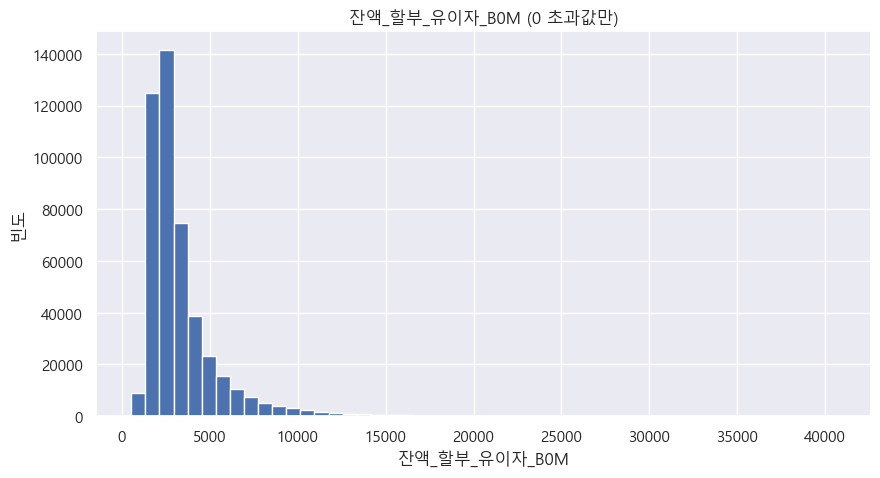

In [405]:
used = all_df[all_df['잔액_할부_유이자_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_할부_유이자_B0M'],
    bins=50,
)
plt.title('잔액_할부_유이자_B0M (0 초과값만)')
plt.xlabel('잔액_할부_유이자_B0M')
plt.ylabel('빈도')
plt.show()

### 잔액_할부_무이자_B0M

In [408]:
all_df['잔액_할부_무이자_B0M'].value_counts()

잔액_할부_무이자_B0M
0        2247265
1620         349
1615         347
1555         340
1712         339
          ...   
12601          1
20583          1
48302          1
25038          1
27201          1
Name: count, Length: 25769, dtype: int64

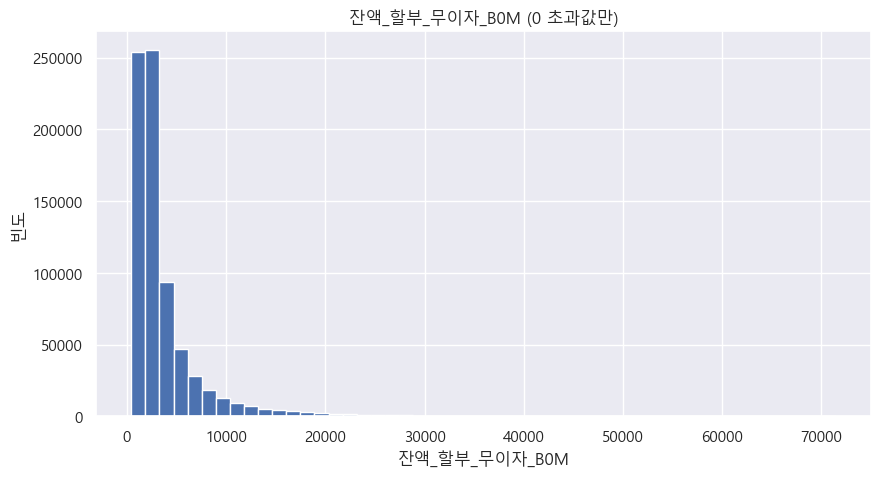

In [410]:
used = all_df[all_df['잔액_할부_무이자_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_할부_무이자_B0M'],
    bins=50,
)
plt.title('잔액_할부_무이자_B0M (0 초과값만)')
plt.xlabel('잔액_할부_무이자_B0M')
plt.ylabel('빈도')
plt.show()

### 잔액_할부_해외_B0M

In [414]:
all_df['잔액_할부_해외_B0M'].value_counts()

잔액_할부_해외_B0M
0       2999305
6041          8
6029          6
6017          6
6039          5
         ...   
5716          1
5748          1
5857          1
6003          1
5427          1
Name: count, Length: 407, dtype: int64

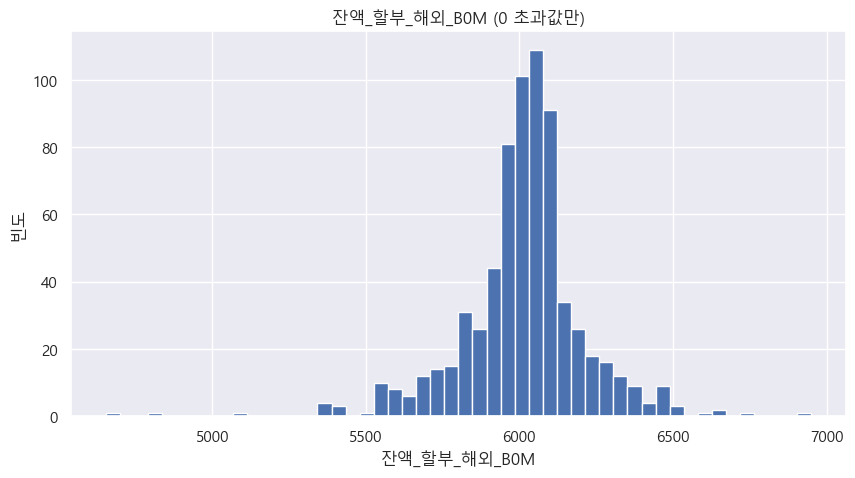

In [412]:
used = all_df[all_df['잔액_할부_해외_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['잔액_할부_해외_B0M'],
    bins=50,
)
plt.title('잔액_할부_해외_B0M (0 초과값만)')
plt.xlabel('잔액_할부_해외_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_일시불_해외_B0M

In [418]:
all_df['연체잔액_일시불_해외_B0M'].value_counts()

연체잔액_일시불_해외_B0M
0    3000000
Name: count, dtype: int64

### 연체잔액_RV일시불_B0M

In [422]:
all_df['연체잔액_RV일시불_B0M'].value_counts()

연체잔액_RV일시불_B0M
0       2999924
1051          3
1035          3
1071          3
1084          2
         ...   
1030          1
1027          1
1060          1
1024          1
1045          1
Name: count, Length: 62, dtype: int64

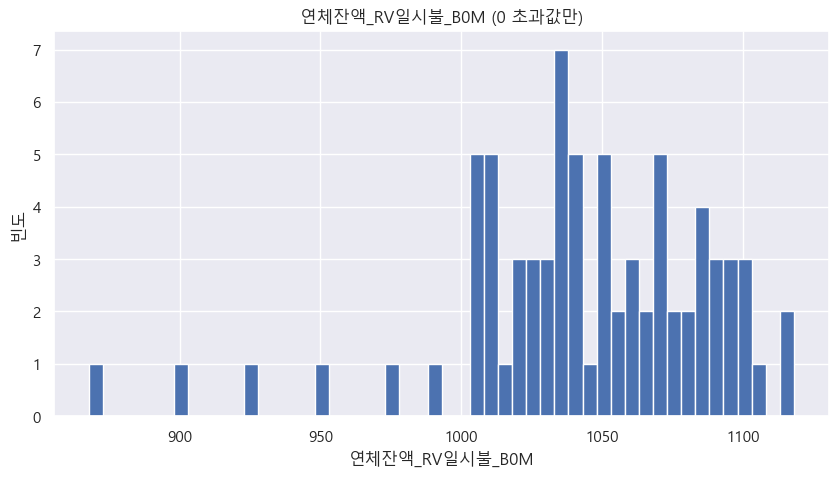

In [424]:
used = all_df[all_df['연체잔액_RV일시불_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_RV일시불_B0M'],
    bins=50,
)
plt.title('연체잔액_RV일시불_B0M (0 초과값만)')
plt.xlabel('연체잔액_RV일시불_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_RV일시불_해외_B0M

In [427]:
all_df['연체잔액_RV일시불_해외_B0M'].value_counts()

연체잔액_RV일시불_해외_B0M
0    3000000
Name: count, dtype: int64

### 연체잔액_할부_해외_B0M

In [431]:
all_df['연체잔액_할부_해외_B0M'].value_counts()

연체잔액_할부_해외_B0M
0    3000000
Name: count, dtype: int64

### 연체잔액_CA_B0M

In [433]:
all_df['연체잔액_CA_B0M'].value_counts()

연체잔액_CA_B0M
0       2998446
8252          7
8255          7
8271          7
8236          6
         ...   
7549          1
8474          1
7890          1
7644          1
8788          1
Name: count, Length: 917, dtype: int64

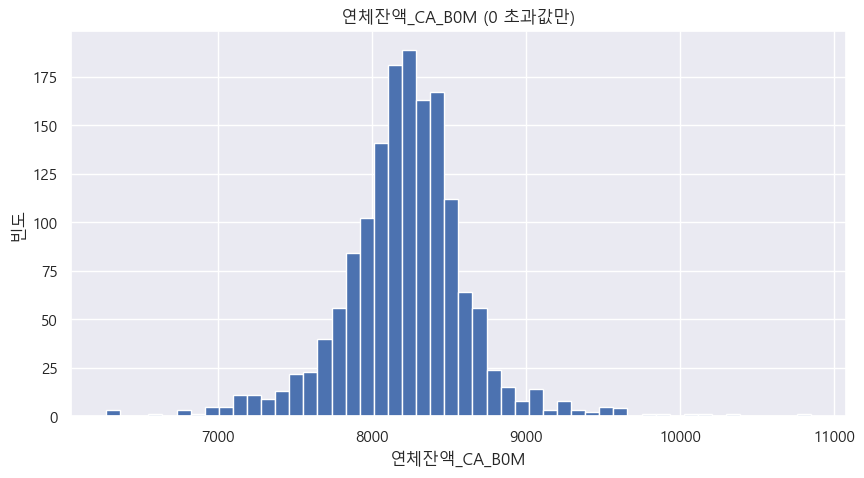

In [436]:
used = all_df[all_df['연체잔액_CA_B0M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['연체잔액_CA_B0M'],
    bins=50,
)
plt.title('연체잔액_CA_B0M (0 초과값만)')
plt.xlabel('연체잔액_CA_B0M')
plt.ylabel('빈도')
plt.show()

### 연체잔액_CA_해외_B0M

In [438]:
all_df['연체잔액_CA_해외_B0M'].value_counts()

연체잔액_CA_해외_B0M
0    3000000
Name: count, dtype: int64

---

## 평균 잔액 (월별, 3개월, 6개월)

- 월별

### 월중평잔

In [456]:
all_df['월중평잔'].value_counts()

월중평잔
0         659123
330702      3811
12          3051
13          3000
14          2957
           ...  
119921         1
90387          1
90327          1
182467         1
95724          1
Name: count, Length: 123145, dtype: int64

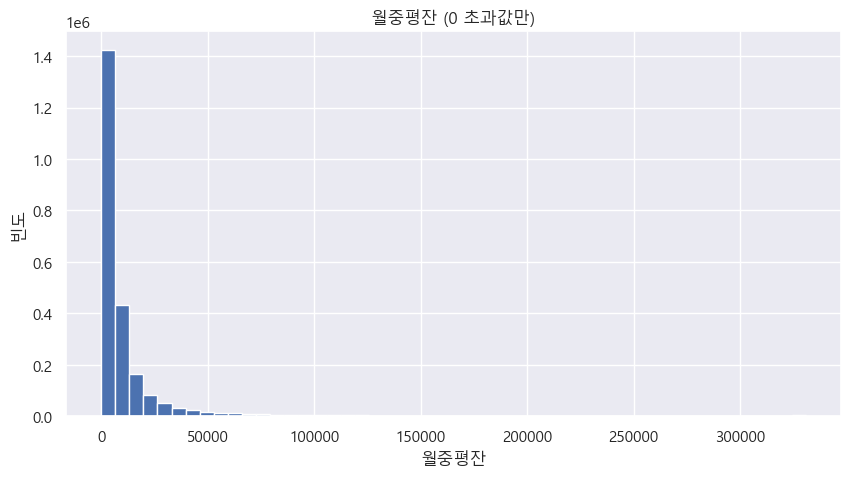

In [469]:
used = all_df[all_df['월중평잔'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔'],
    bins=50,
)
plt.title('월중평잔 (0 초과값만)')
plt.xlabel('월중평잔')
plt.ylabel('빈도')
plt.show()

### 월중평잔_일시불

In [458]:
all_df['월중평잔_일시불'].value_counts()

월중평잔_일시불
0        758178
9          3391
10         3296
8          3276
11         3224
          ...  
62585         1
31821         1
44476         1
57133         1
59038         1
Name: count, Length: 52098, dtype: int64

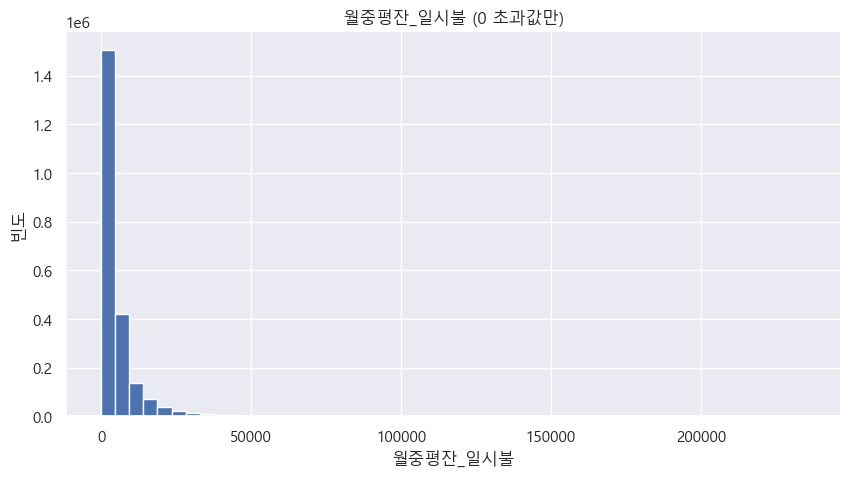

In [471]:
used = all_df[all_df['월중평잔_일시불'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_일시불'],
    bins=50,
)
plt.title('월중평잔_일시불 (0 초과값만)')
plt.xlabel('월중평잔_일시불')
plt.ylabel('빈도')
plt.show()

### 월중평잔_RV일시불

In [460]:
all_df['월중평잔_RV일시불'].value_counts()

월중평잔_RV일시불
0        2522016
2175         136
1909         136
2114         135
2067         135
          ...   
27945          1
34885          1
37492          1
44891          1
39492          1
Name: count, Length: 40774, dtype: int64

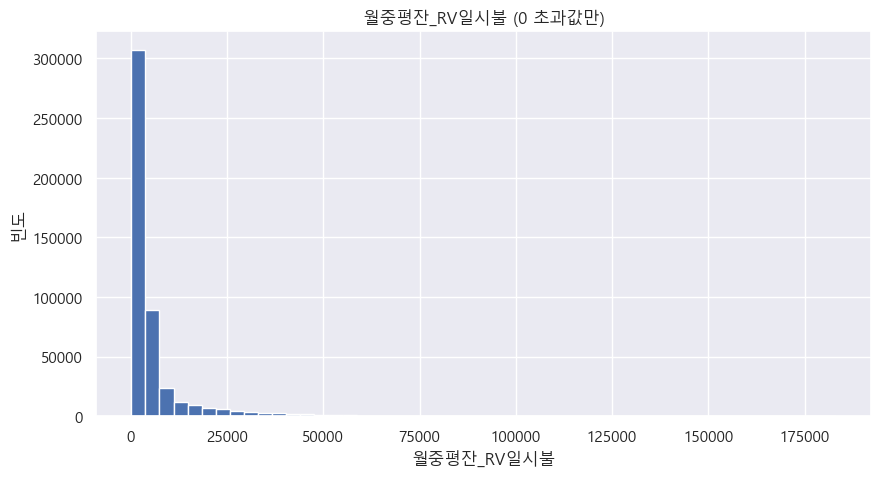

In [473]:
used = all_df[all_df['월중평잔_RV일시불'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_RV일시불'],
    bins=50,
)
plt.title('월중평잔_RV일시불 (0 초과값만)')
plt.xlabel('월중평잔_RV일시불')
plt.ylabel('빈도')
plt.show()

### 월중평잔_할부

In [462]:
all_df['월중평잔_할부'].value_counts()

월중평잔_할부
0        1949627
1094         429
1134         405
1309         404
1023         403
          ...   
34879          1
38530          1
27181          1
39628          1
49664          1
Name: count, Length: 44850, dtype: int64

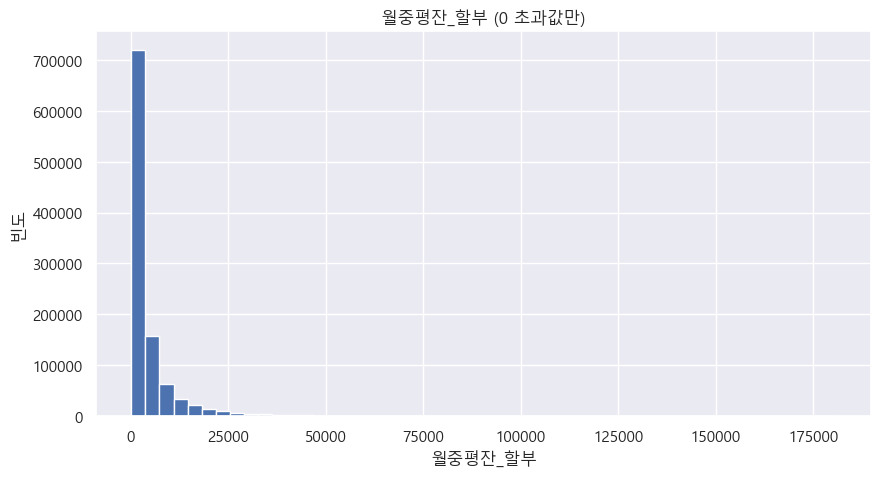

In [475]:
used = all_df[all_df['월중평잔_할부'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_할부'],
    bins=50,
)
plt.title('월중평잔_할부 (0 초과값만)')
plt.xlabel('월중평잔_할부')
plt.ylabel('빈도')
plt.show()

### 월중평잔_CA

In [464]:
all_df['월중평잔_CA'].value_counts()

월중평잔_CA
0        2817039
3308          41
3273          39
3774          38
3398          38
          ...   
30245          1
27125          1
56261          1
18927          1
25167          1
Name: count, Length: 37889, dtype: int64

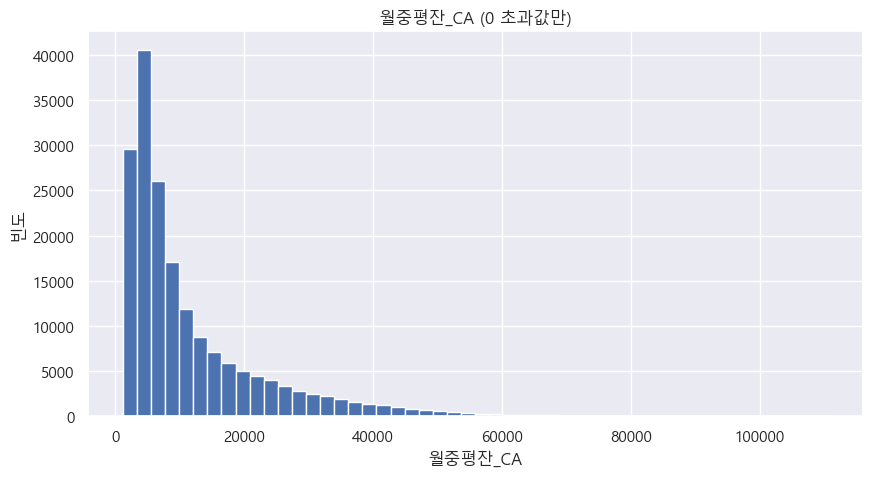

In [477]:
used = all_df[all_df['월중평잔_CA'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_CA'],
    bins=50,
)
plt.title('월중평잔_CA (0 초과값만)')
plt.xlabel('월중평잔_CA')
plt.ylabel('빈도')
plt.show()

### 월중평잔_카드론

In [466]:
all_df['월중평잔_카드론'].value_counts()

월중평잔_카드론
0         2814054
241790         23
18981          16
16738          14
14183          13
           ...   
54369           1
44508           1
155098          1
60084           1
118548          1
Name: count, Length: 75835, dtype: int64

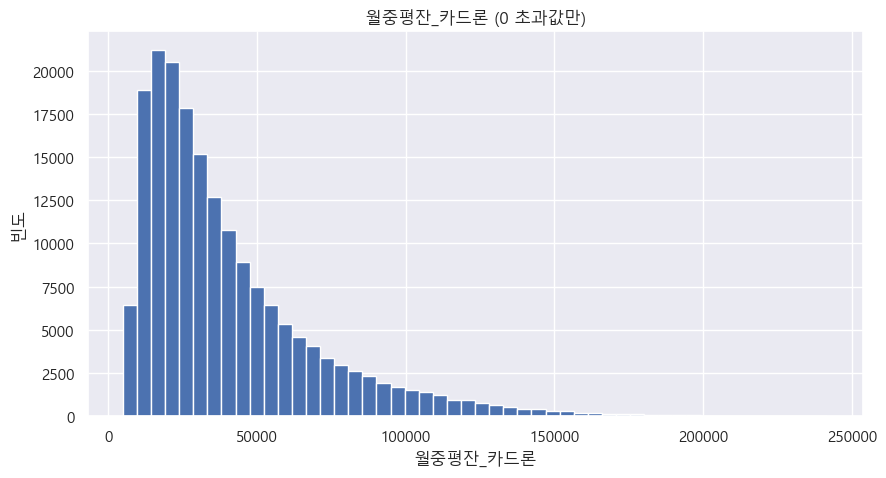

In [479]:
used = all_df[all_df['월중평잔_카드론'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['월중평잔_카드론'],
    bins=50,
)
plt.title('월중평잔_카드론 (0 초과값만)')
plt.xlabel('월중평잔_카드론')
plt.ylabel('빈도')
plt.show()

- 3개월

### 평잔_3M

In [481]:
all_df['평잔_3M'].value_counts()

평잔_3M
0         593455
311938      5543
8           4379
9           4049
7           3885
           ...  
196092         1
214427         1
206175         1
104017         1
189089         1
Name: count, Length: 129221, dtype: int64

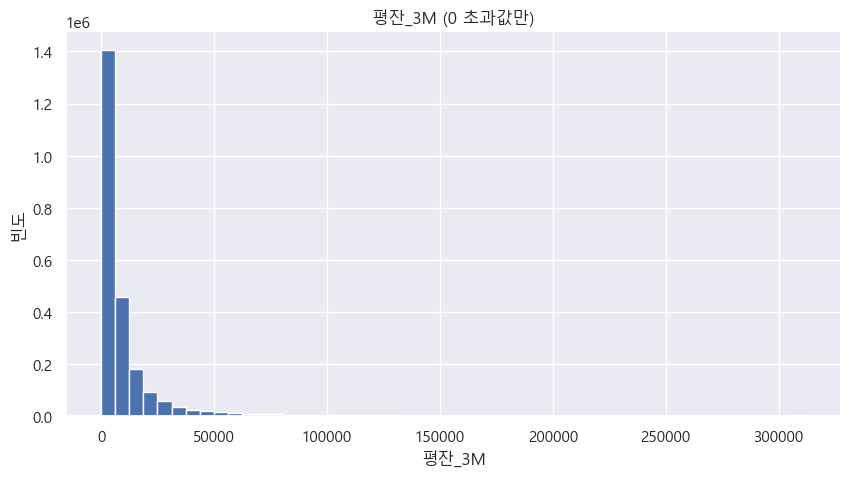

In [523]:
used = all_df[all_df['평잔_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_3M'],
    bins=50,
)
plt.title('평잔_3M (0 초과값만)')
plt.xlabel('평잔_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_일시불_3M

In [483]:
all_df['평잔_일시불_3M'].value_counts()

평잔_일시불_3M
0        679404
7          5359
6          5142
8          4898
5          4700
          ...  
44049         1
44890         1
92765         1
41223         1
60155         1
Name: count, Length: 54147, dtype: int64

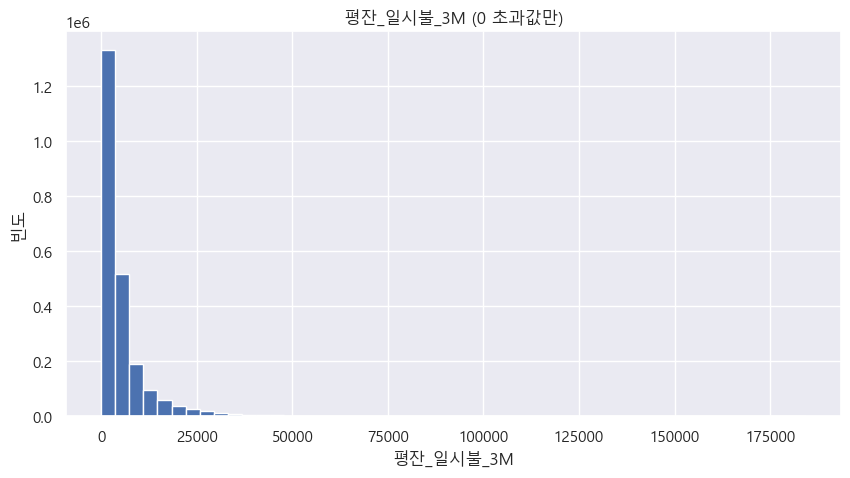

In [525]:
used = all_df[all_df['평잔_일시불_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_일시불_3M'],
    bins=50,
)
plt.title('평잔_일시불_3M (0 초과값만)')
plt.xlabel('평잔_일시불_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_일시불_해외_3M

In [485]:
all_df['평잔_일시불_해외_3M'].value_counts()

평잔_일시불_해외_3M
0       2664595
305        1599
298        1589
323        1575
300        1567
         ...   
1949          1
1477          1
1375          1
1560          1
1421          1
Name: count, Length: 1496, dtype: int64

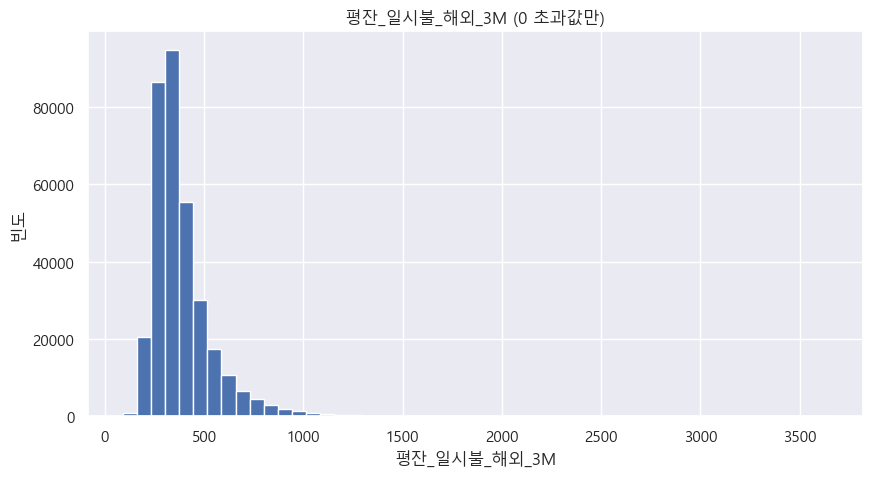

In [527]:
used = all_df[all_df['평잔_일시불_해외_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_일시불_해외_3M'],
    bins=50,
)
plt.title('평잔_일시불_해외_3M (0 초과값만)')
plt.xlabel('평잔_일시불_해외_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_RV일시불_3M

In [487]:
all_df['평잔_RV일시불_3M'].value_counts()

평잔_RV일시불_3M
0        2513515
1550         129
1756         128
1789         127
1816         125
          ...   
58500          1
33657          1
30273          1
61982          1
22692          1
Name: count, Length: 43133, dtype: int64

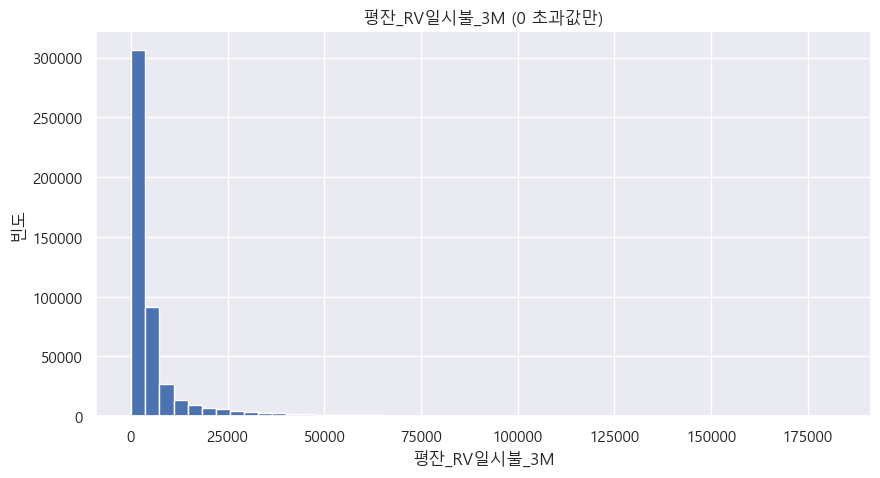

In [529]:
used = all_df[all_df['평잔_RV일시불_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_RV일시불_3M'],
    bins=50,
)
plt.title('평잔_RV일시불_3M (0 초과값만)')
plt.xlabel('평잔_RV일시불_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_RV일시불_해외_3M

In [489]:
all_df['평잔_RV일시불_해외_3M'].value_counts()

평잔_RV일시불_해외_3M
0      2921584
393        591
399        589
397        586
387        573
        ...   
201          1
979          1
865          1
965          1
830          1
Name: count, Length: 756, dtype: int64

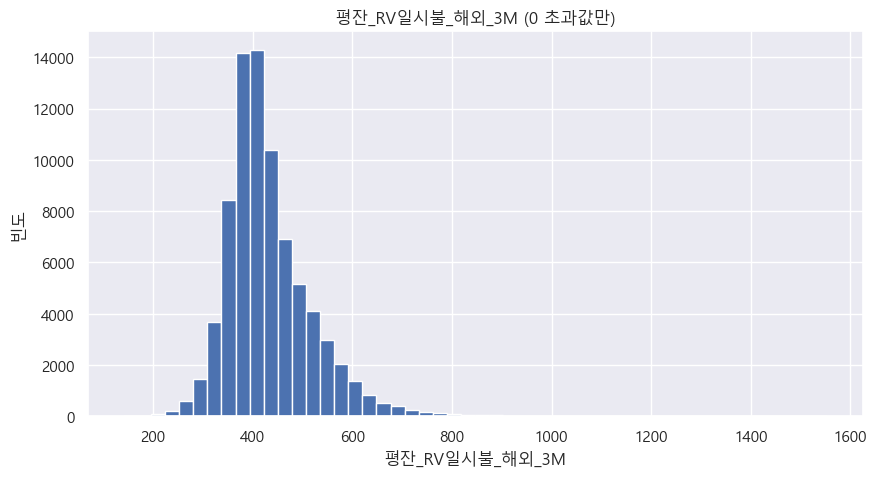

In [531]:
used = all_df[all_df['평잔_RV일시불_해외_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_RV일시불_해외_3M'],
    bins=50,
)
plt.title('평잔_RV일시불_해외_3M (0 초과값만)')
plt.xlabel('평잔_RV일시불_해외_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_할부_3M

In [491]:
all_df['평잔_할부_3M'].value_counts()

평잔_할부_3M
0        1855177
620          401
673          385
623          385
480          383
          ...   
24400          1
60143          1
62360          1
66119          1
59240          1
Name: count, Length: 51058, dtype: int64

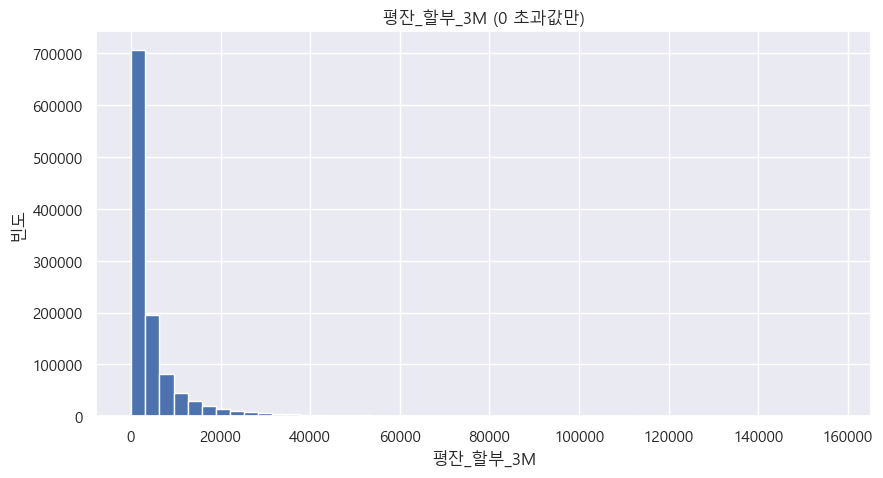

In [533]:
used = all_df[all_df['평잔_할부_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_할부_3M'],
    bins=50,
)
plt.title('평잔_할부_3M (0 초과값만)')
plt.xlabel('평잔_할부_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_할부_해외_3M

In [493]:
all_df['평잔_할부_해외_3M'].value_counts()

평잔_할부_해외_3M
0       2997415
4357         15
4335         15
4323         14
4388         14
         ...   
3917          1
4780          1
4778          1
4762          1
4539          1
Name: count, Length: 793, dtype: int64

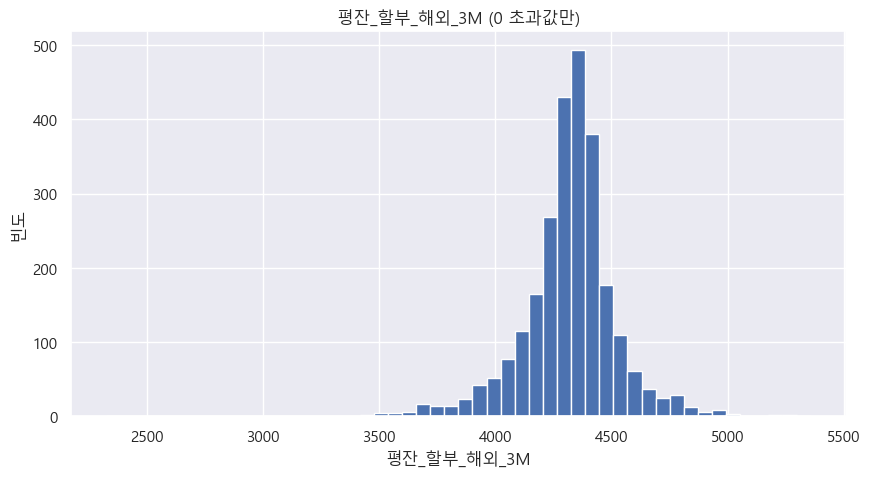

In [548]:
used = all_df[all_df['평잔_할부_해외_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_할부_해외_3M'],
    bins=50,
)
plt.title('평잔_할부_해외_3M (0 초과값만)')
plt.xlabel('평잔_할부_해외_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_CA_3M

In [495]:
all_df['평잔_CA_3M'].value_counts()

평잔_CA_3M
0        2757524
1281          87
1355          85
1285          84
1098          83
          ...   
23000          1
36927          1
36386          1
52583          1
35852          1
Name: count, Length: 44713, dtype: int64

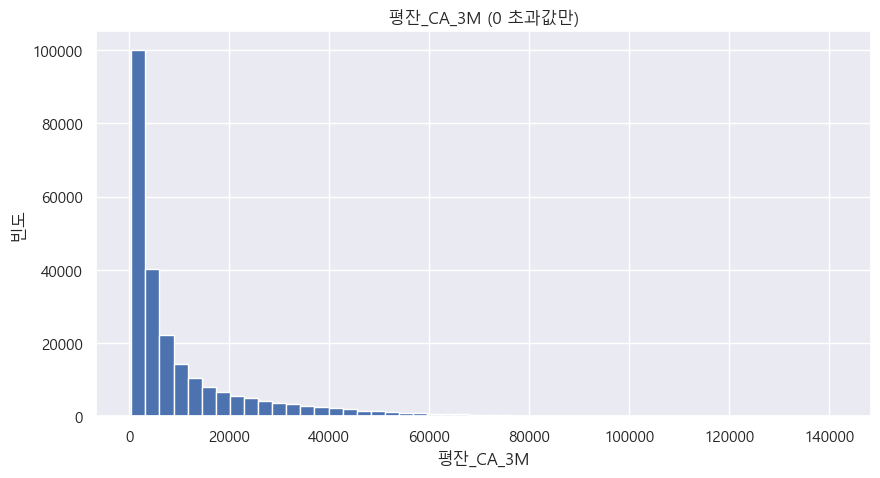

In [551]:
used = all_df[all_df['평잔_CA_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_CA_3M'],
    bins=50,
)
plt.title('평잔_CA_3M (0 초과값만)')
plt.xlabel('평잔_CA_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_CA_해외_3M

In [497]:
all_df['평잔_CA_해외_3M'].value_counts()

평잔_CA_해외_3M
0       2999772
1775          7
1805          6
1797          5
1788          5
         ...   
1906          1
1661          1
1696          1
1549          1
1868          1
Name: count, Length: 126, dtype: int64

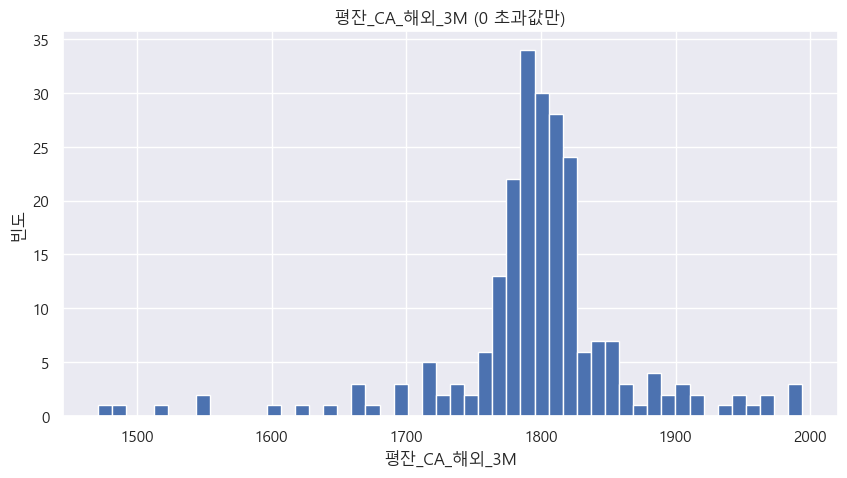

In [554]:
used = all_df[all_df['평잔_CA_해외_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_CA_해외_3M'],
    bins=50,
)
plt.title('평잔_CA_해외_3M (0 초과값만)')
plt.xlabel('평잔_CA_해외_3M')
plt.ylabel('빈도')
plt.show()

### 평잔_카드론_3M

In [499]:
all_df['평잔_카드론_3M'].value_counts()

평잔_카드론_3M
0         2799754
230000        645
13729          15
11873          15
18341          14
           ...   
128761          1
127646          1
87288           1
67655           1
109338          1
Name: count, Length: 84194, dtype: int64

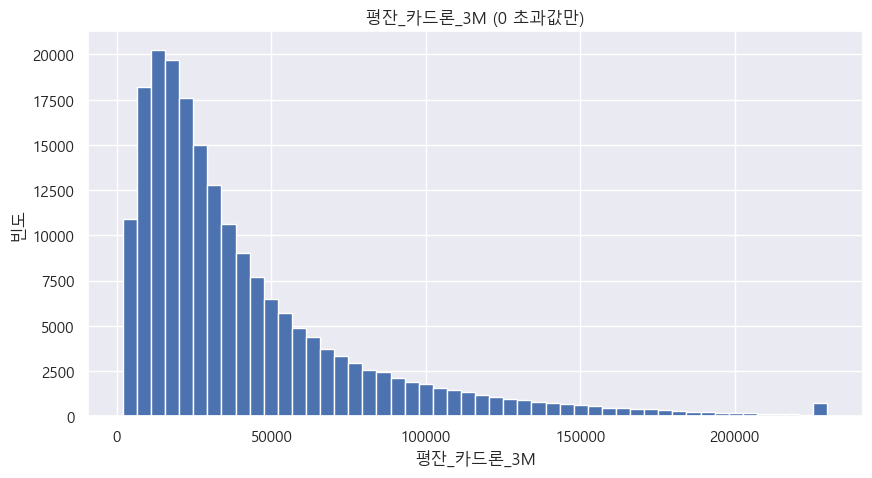

In [557]:
used = all_df[all_df['평잔_카드론_3M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_카드론_3M'],
    bins=50,
)
plt.title('평잔_카드론_3M (0 초과값만)')
plt.xlabel('평잔_카드론_3M')
plt.ylabel('빈도')
plt.show()

- 6개월

### 평잔_6M

In [503]:
all_df['평잔_6M'].value_counts()

평잔_6M
0         483092
299154      7048
8           3903
9           3753
7           3609
           ...  
66864          1
134999         1
162848         1
242345         1
85486          1
Name: count, Length: 135316, dtype: int64

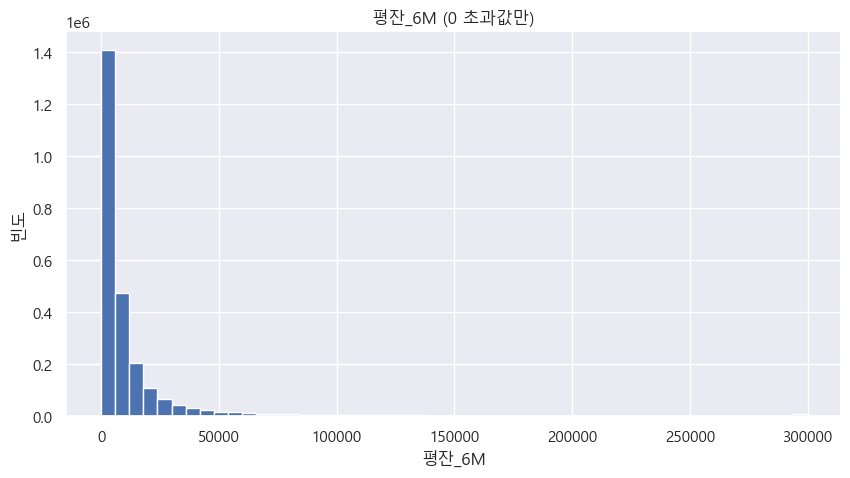

In [560]:
used = all_df[all_df['평잔_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_6M'],
    bins=50,
)
plt.title('평잔_6M (0 초과값만)')
plt.xlabel('평잔_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_일시불_6M

In [505]:
all_df['평잔_일시불_6M'].value_counts()

평잔_일시불_6M
0        553438
6          5768
7          5335
5          5049
8          4503
          ...  
67701         1
42462         1
35793         1
42392         1
51854         1
Name: count, Length: 53232, dtype: int64

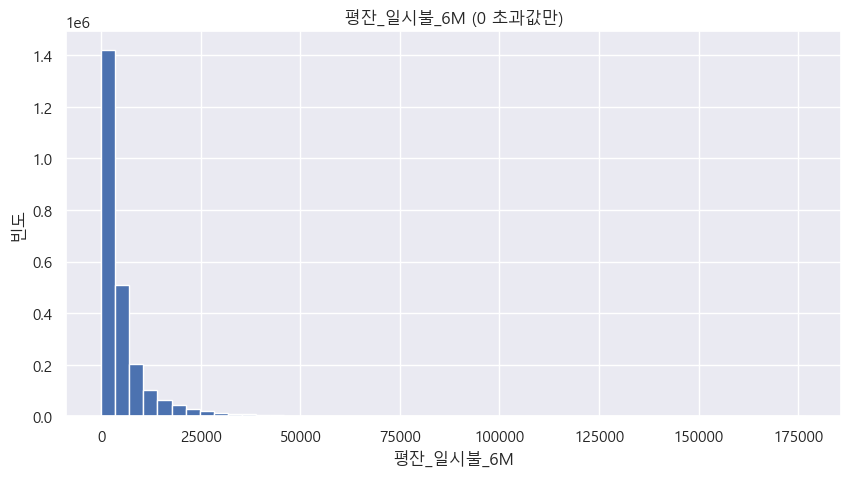

In [563]:
used = all_df[all_df['평잔_일시불_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_일시불_6M'],
    bins=50,
)
plt.title('평잔_일시불_6M (0 초과값만)')
plt.xlabel('평잔_일시불_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_일시불_해외_6M

In [507]:
all_df['평잔_일시불_해외_6M'].value_counts()

평잔_일시불_해외_6M
0       2622106
243        1609
256        1603
244        1595
245        1593
         ...   
1415          1
2057          1
1887          1
1796          1
1554          1
Name: count, Length: 1771, dtype: int64

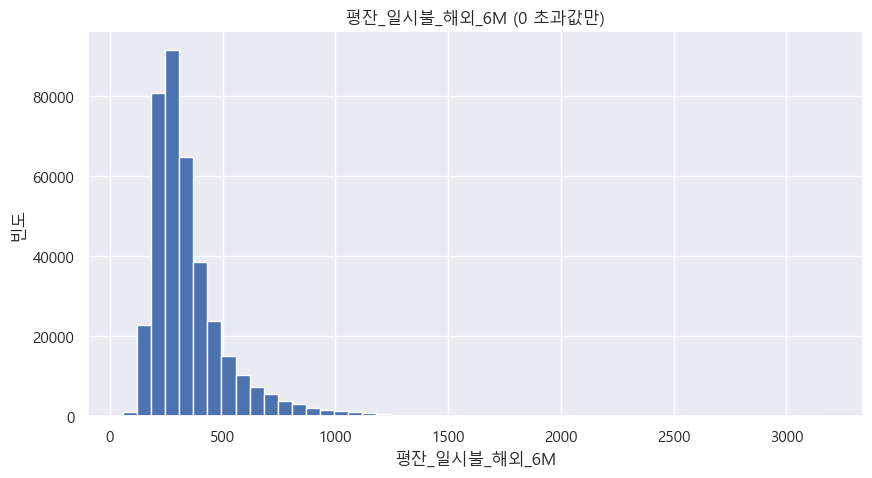

In [566]:
used = all_df[all_df['평잔_일시불_해외_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_일시불_해외_6M'],
    bins=50,
)
plt.title('평잔_일시불_해외_6M (0 초과값만)')
plt.xlabel('평잔_일시불_해외_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_RV일시불_6M

In [509]:
all_df['평잔_RV일시불_6M'].value_counts()

평잔_RV일시불_6M
0        2495645
314          152
296          146
284          144
306          142
          ...   
28700          1
67719          1
44454          1
26537          1
76950          1
Name: count, Length: 42829, dtype: int64

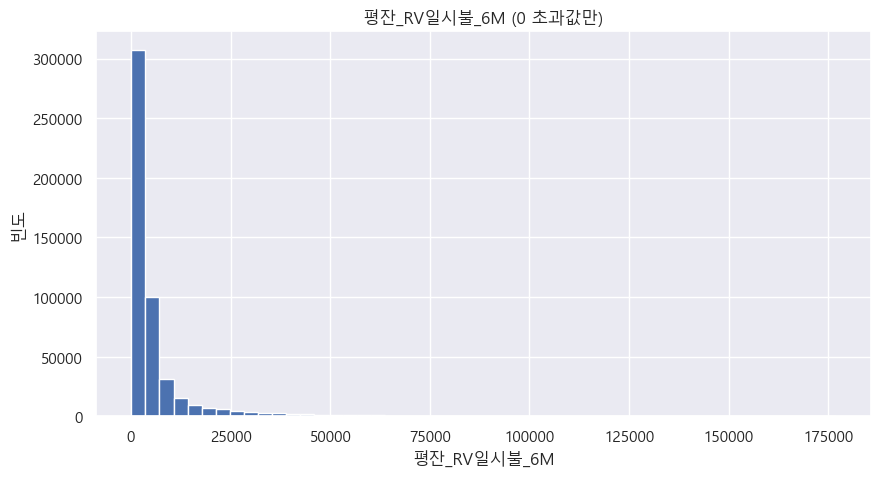

In [569]:
used = all_df[all_df['평잔_RV일시불_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_RV일시불_6M'],
    bins=50,
)
plt.title('평잔_RV일시불_6M (0 초과값만)')
plt.xlabel('평잔_RV일시불_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_RV일시불_해외_6M

In [511]:
all_df['평잔_RV일시불_해외_6M'].value_counts()

평잔_RV일시불_해외_6M
0      2914045
346        603
341        599
337        598
349        594
        ...   
776          1
146          1
855          1
850          1
864          1
Name: count, Length: 636, dtype: int64

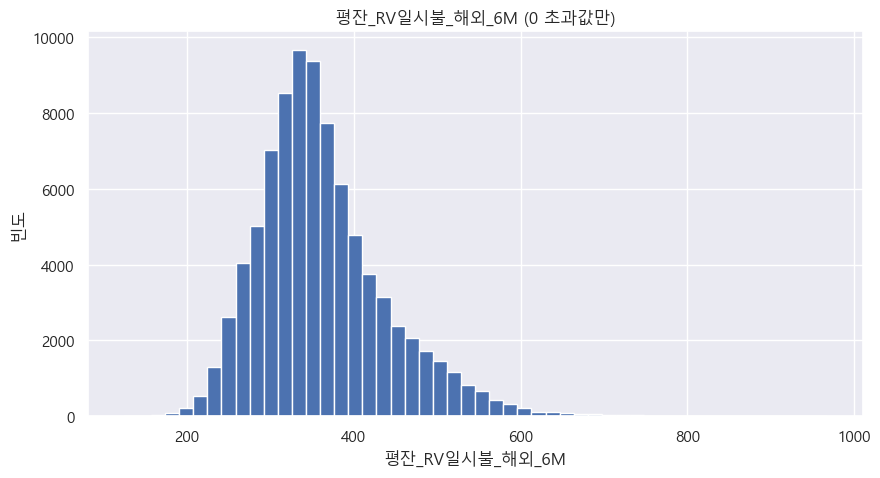

In [572]:
used = all_df[all_df['평잔_RV일시불_해외_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_RV일시불_해외_6M'],
    bins=50,
)
plt.title('평잔_RV일시불_해외_6M (0 초과값만)')
plt.xlabel('평잔_RV일시불_해외_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_할부_6M

In [513]:
all_df['평잔_할부_6M'].value_counts()

평잔_할부_6M
0        1691900
348          534
316          530
329          530
357          528
          ...   
57435          1
52992          1
85058          1
44719          1
95571          1
Name: count, Length: 55468, dtype: int64

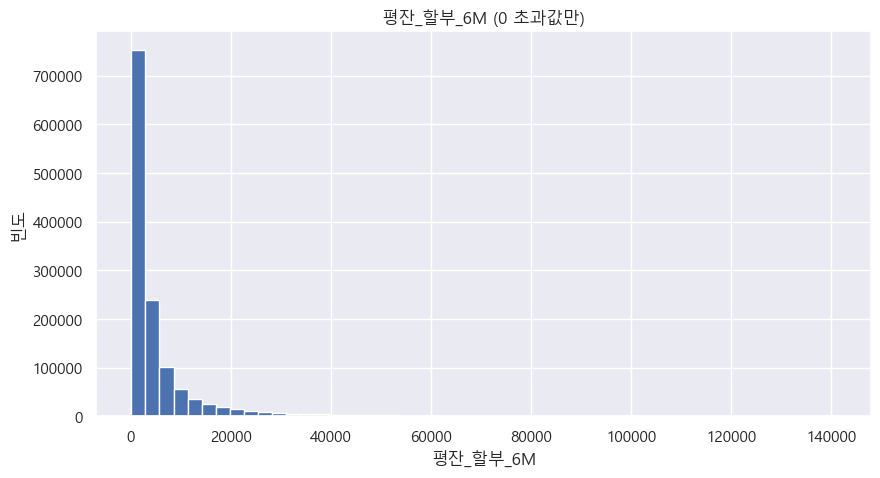

In [574]:
used = all_df[all_df['평잔_할부_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_할부_6M'],
    bins=50,
)
plt.title('평잔_할부_6M (0 초과값만)')
plt.xlabel('평잔_할부_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_할부_해외_6M

In [515]:
all_df['평잔_할부_해외_6M'].value_counts()

평잔_할부_해외_6M
0       2996359
1274         27
1273         26
1270         25
1269         24
         ...   
970           1
1052          1
1634          1
1501          1
1432          1
Name: count, Length: 662, dtype: int64

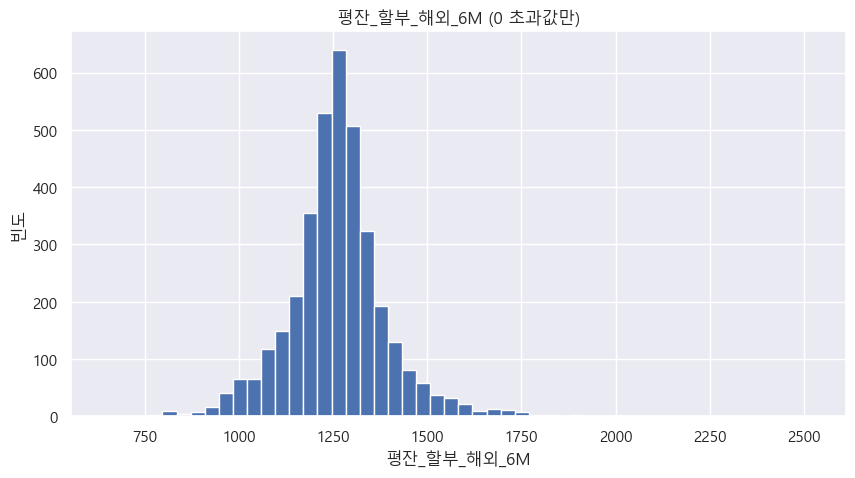

In [578]:
used = all_df[all_df['평잔_할부_해외_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_할부_해외_6M'],
    bins=50,
)
plt.title('평잔_할부_해외_6M (0 초과값만)')
plt.xlabel('평잔_할부_해외_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_CA_6M

In [517]:
all_df['평잔_CA_6M'].value_counts()

평잔_CA_6M
0        2705146
628          169
677          166
684          164
668          164
          ...   
30808          1
39183          1
35771          1
32026          1
38176          1
Name: count, Length: 46351, dtype: int64

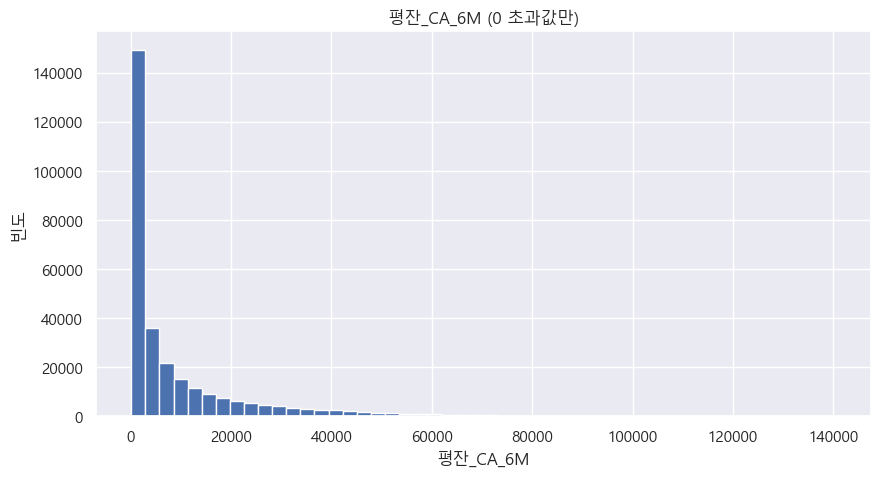

In [581]:
used = all_df[all_df['평잔_CA_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_CA_6M'],
    bins=50,
)
plt.title('평잔_CA_6M (0 초과값만)')
plt.xlabel('평잔_CA_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_CA_해외_6M

In [519]:
all_df['평잔_CA_해외_6M'].value_counts()

평잔_CA_해외_6M
0       2999284
1212         15
1208         15
1200         14
1214         11
         ...   
1297          1
1079          1
1364          1
1301          1
1356          1
Name: count, Length: 226, dtype: int64

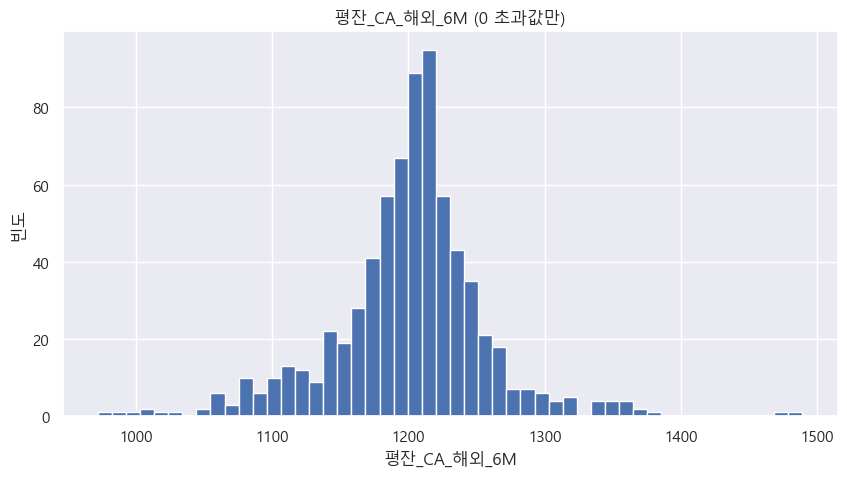

In [585]:
used = all_df[all_df['평잔_CA_해외_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_CA_해외_6M'],
    bins=50,
)
plt.title('평잔_CA_해외_6M (0 초과값만)')
plt.xlabel('평잔_CA_해외_6M')
plt.ylabel('빈도')
plt.show()

### 평잔_카드론_6M

In [521]:
all_df['평잔_카드론_6M'].value_counts()

평잔_카드론_6M
0         2775436
225000       1042
6552           17
12247          16
10850          16
           ...   
118945          1
94111           1
70680           1
57352           1
152223          1
Name: count, Length: 89542, dtype: int64

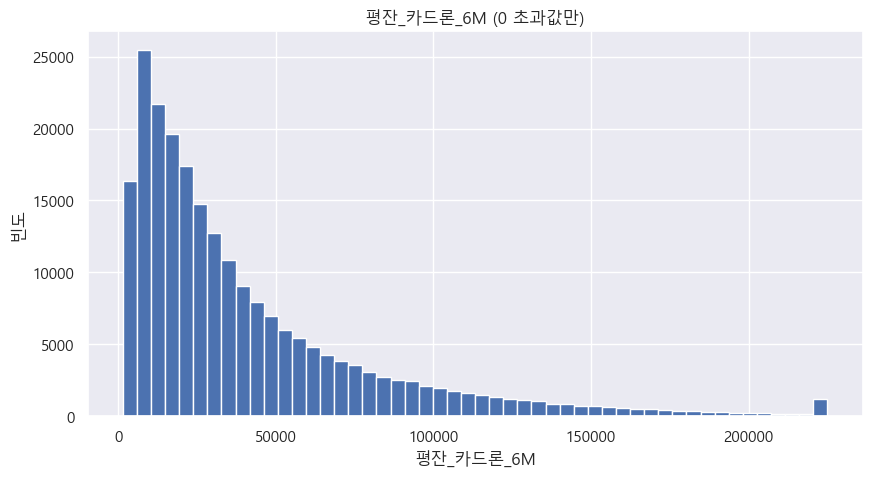

In [588]:
used = all_df[all_df['평잔_카드론_6M'] > 0]

plt.figure(figsize=(10, 5))
plt.hist(
    used['평잔_카드론_6M'],
    bins=50,
)
plt.title('평잔_카드론_6M (0 초과값만)')
plt.xlabel('평잔_카드론_6M')
plt.ylabel('빈도')
plt.show()